# 03. Feature Importance & XAI

**최종 성능이 가장 좋은 SVM을 대표 모델로 선택**하고, 그 모델을 중심으로 XAI를 정리.
LightGBM은 해석 결과를 비교하거나 보조 근거를 제시하는 참고 모델로 사용.



## 이번 노트북에서 생성하는 그래프

1. SVM 상위 중요 변수 (permutation 기준)
2. SVM 클래스별 핵심 변수 비교
3. AI 관련 변수 중요도 비교 (SVM 중심)
4. LightGBM-SVM 공통 핵심 변수 비교
5. 모델별 상위 변수의 도메인 구성 비교
6. LightGBM 상위 중요 변수 (gain 기준, 비교용)
7. LightGBM 상위 중요 변수 (split 기준, 비교용)
8. LIME 설명: 1단계 대표 사례
9. LIME 설명: 3단계 대표 사례
10. LIME 사례별 주요 기여 변수 비교
11. SVM SHAP 전역 중요도
12. SVM SHAP 클래스별 중요도 히트맵
13. SHAP 설명: 1단계 대표 사례
14. SHAP 설명: 3단계 대표 사례
15. SHAP / LIME 정리 및 다음 단계 안내


In [1]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["axes.unicode_minus"] = False

available_fonts = {f.name for f in fm.fontManager.ttflist}
font_candidates = ["NanumGothic", "AppleGothic", "Malgun Gothic", "DejaVu Sans"]
selected_font = next((font for font in font_candidates if font in available_fonts), "DejaVu Sans")
plt.rcParams["font.family"] = selected_font

ROOT = Path.cwd().resolve()
if not (ROOT / "models").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

MODELS_DIR = ROOT / "models"
OUT_DIR = ROOT / "outputs" / "figures" / "feature_xai"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ROOT, OUT_DIR, selected_font


(PosixPath('/Users/minseo/Desktop/3-2/machine learning/Team-3'),
 PosixPath('/Users/minseo/Desktop/3-2/machine learning/Team-3/outputs/figures/feature_xai'),
 'AppleGothic')

In [2]:
import importlib
import src.xai_utils as xai_utils
importlib.reload(xai_utils)
from src.xai_utils import concise_feature_label, make_unique_display_labels

def save_fig(filename: str):
    plt.tight_layout(rect=[0.04, 0.03, 0.98, 0.95], pad=1.6)
    plt.savefig(OUT_DIR / filename, bbox_inches="tight", facecolor="white")
    plt.show()


def apply_common_style(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)


def set_axis_text(ax, title, xlabel, ylabel, title_size=18):
    ax.set_title(title, fontsize=title_size, fontweight="bold", pad=16)
    ax.set_xlabel(xlabel, fontweight="bold", labelpad=10)
    ax.set_ylabel(ylabel, fontweight="bold", labelpad=10)


def add_horizontal_values(ax, decimals=3):
    for p in ax.patches:
        width = p.get_width()
        if pd.isna(width) or width <= 0:
            continue
        ax.text(
            width,
            p.get_y() + p.get_height() / 2,
            f" {width:.{decimals}f}",
            va="center",
            ha="left",
            fontsize=9,
            fontweight="bold",
        )


def shorten_label(feature, text, max_len=10):
    return concise_feature_label(feature, text, max_len=max_len)


def infer_domain(feature, label):
    if feature.startswith("AI_"):
        return "AI 경험"
    m = re.match(r"Q(\d+)", feature)
    q_num = int(m.group(1)) if m else None
    if q_num in [1, 2, 3, 4, 5]:
        return "기기 접근 / 문제 해결"
    if q_num == 6:
        return "PC 기본 역량"
    if q_num == 7:
        return "모바일 기본 역량"
    if q_num == 8:
        return "디지털 활용 역량"
    if q_num == 9:
        return "디지털 참여 / 예방 / 소양"
    if q_num in [10, 11]:
        return "이용 빈도 / 접속"
    if q_num == 12:
        return "검색 / 콘텐츠 이용"
    if q_num == 13:
        return "사회적 관계 서비스"
    if q_num == 14:
        return "생활 서비스"
    if q_num == 15:
        return "정보 생산 / 공유"
    if q_num == 16:
        return "네트워킹"
    if q_num == 17:
        return "사회 참여"
    if q_num == 18:
        return "경제 활동"
    if q_num == 19:
        return "심화 디지털 기술"
    if q_num == 21:
        return "디지털 태도"
    if q_num == 22:
        return "디지털 효능감"
    return "기타"


In [3]:
feature_meta = pd.read_csv(MODELS_DIR / "MLP" / "models_feature_selection.csv", encoding="utf-8-sig")
feature_meta = feature_meta[["feature", "label"]].copy()
feature_meta["base_short"] = feature_meta.apply(lambda r: concise_feature_label(r["feature"], r["label"], max_len=10), axis=1)
feature_meta["label_short"] = make_unique_display_labels(
    feature_meta["feature"].tolist(),
    feature_meta["label"].tolist(),
    feature_meta["base_short"].tolist(),
)
feature_meta["domain"] = feature_meta.apply(lambda r: infer_domain(r["feature"], r["label"]), axis=1)

lgbm_imp = pd.read_csv(MODELS_DIR / "LightGBM" / "lgbm_feature_importance.csv")
svm_perm = pd.read_csv(MODELS_DIR / "SVM" / "svm_permutation_importance.csv")
svm_coef = pd.read_csv(MODELS_DIR / "SVM" / "svm_coef_by_class.csv")

lgbm_imp = lgbm_imp.merge(feature_meta, on="feature", how="left")
svm_perm = svm_perm.merge(feature_meta, on="feature", how="left")
svm_coef = svm_coef.merge(feature_meta, on="feature", how="left")

lgbm_imp.head()


,feature,importance_split,importance_gain,label,base_short,label_short,domain
0,AI_사용빈도,166,1146.427558,(Q27B 합산),AI 사용 빈도,AI 사용 빈도,AI 경험
1,AI_도움정도,124,210.409661,(Q27C 합산),AI 도움 정도,AI 도움 정도,AI 경험
2,Q13A_2,107,2613.927552,문13. 사회적 관계 서비스 이용 비율_PC_2) 메신저,메신저,메신저 (Q13A2),사회적 관계 서비스
3,Q9_2,101,2319.299447,문9. 디지털역량 진단지수 중 참여/예방/소양역량- 2) 정치/사회 문제 토론 또는...,온라인 의견 개진,온라인 의견 개진 (Q92),디지털 참여 / 예방 / 소양
4,Q11_1,100,638.821147,"문11. 최근 한 달 이용 일수_1) PC(데스크탑, 노트북)",PC,PC (Q111),이용 빈도 / 접속


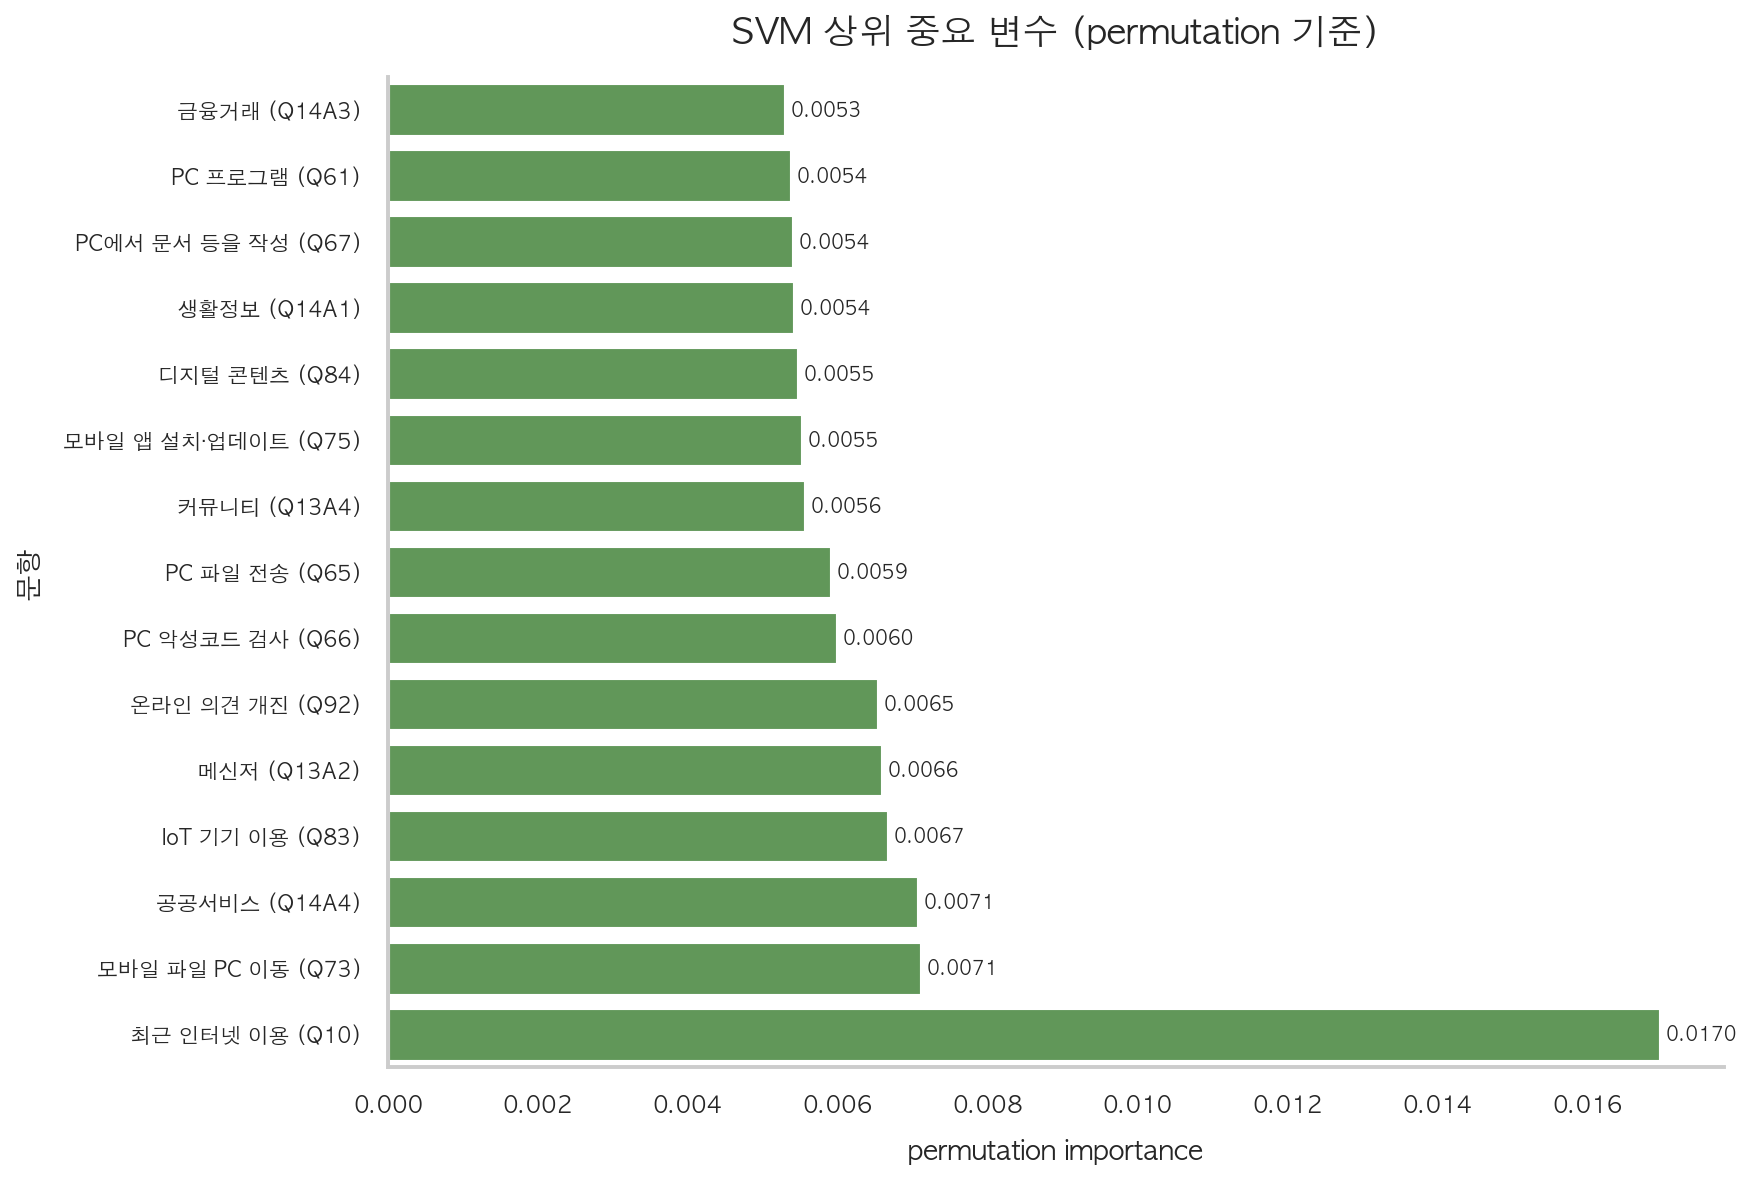

,feature,label_short,perm_importance,domain
0,Q10,최근 인터넷 이용 (Q10),0.016969,이용 빈도 / 접속
1,Q7_3,모바일 파일 PC 이동 (Q73),0.007116,모바일 기본 역량
2,Q14A_4,공공서비스 (Q14A4),0.007064,생활 서비스
3,Q8_3,IoT 기기 이용 (Q83),0.006669,디지털 활용 역량
4,Q13A_2,메신저 (Q13A2),0.006594,사회적 관계 서비스
5,Q9_2,온라인 의견 개진 (Q92),0.006539,디지털 참여 / 예방 / 소양
6,Q6_6,PC 악성코드 검사 (Q66),0.005987,PC 기본 역량
7,Q6_5,PC 파일 전송 (Q65),0.005906,PC 기본 역량
8,Q13A_4,커뮤니티 (Q13A4),0.005557,사회적 관계 서비스
9,Q7_5,모바일 앱 설치·업데이트 (Q75),0.005520,모바일 기본 역량


In [4]:
# 1. SVM 상위 중요 변수 (permutation 기준)
top_svm_perm = svm_perm.sort_values("perm_importance", ascending=False).head(15).sort_values("perm_importance")

plt.figure(figsize=(13.0, 9.2))
ax = sns.barplot(data=top_svm_perm, x="perm_importance", y="label_short", color="#59A14F", errorbar=None)
set_axis_text(ax, "SVM 상위 중요 변수 (permutation 기준)", "permutation importance", "문항", title_size=17)
ax.tick_params(axis="y", labelsize=10)
apply_common_style(ax)
add_horizontal_values(ax, decimals=4)
save_fig("01_svm_top_permutation.png")

top_svm_perm[["feature", "label_short", "perm_importance", "domain"]].sort_values("perm_importance", ascending=False)


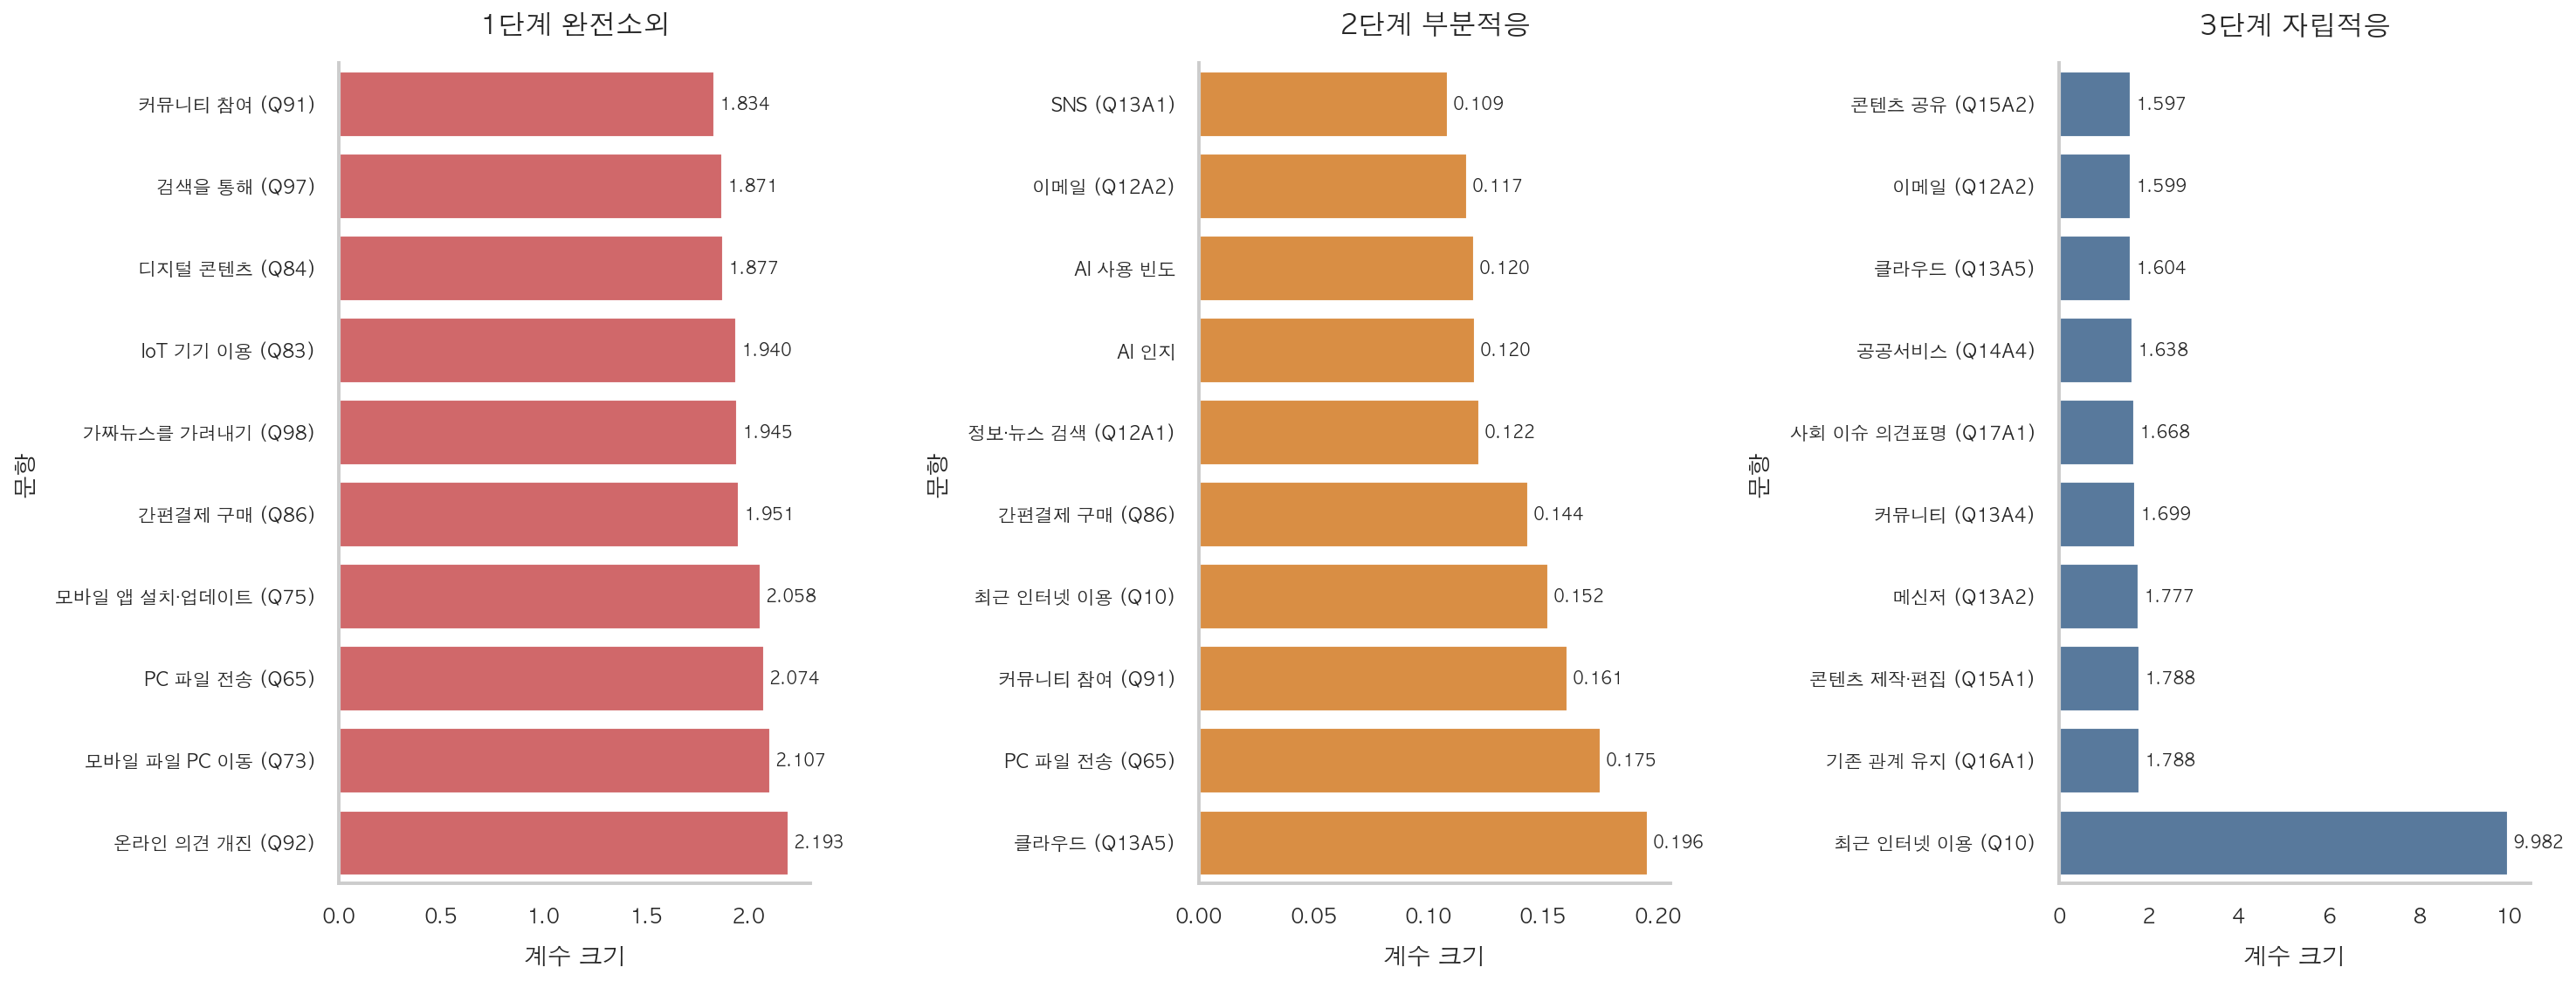

In [5]:
# 2. SVM 클래스별 핵심 변수 비교
top_coef = svm_coef[svm_coef["rank"] <= 10].copy()

fig, axes = plt.subplots(1, 3, figsize=(21.5, 8.8), sharex=False)
class_order = ["1단계_완전소외", "2단계_부분적응", "3단계_자립적응"]
colors = ["#E15759", "#F28E2B", "#4C78A8"]

for ax, class_name, color in zip(axes, class_order, colors):
    sub = top_coef[top_coef["class_name"] == class_name].sort_values("abs_coef")
    sns.barplot(data=sub, x="abs_coef", y="label_short", color=color, errorbar=None, ax=ax)
    set_axis_text(ax, class_name.replace("_", " "), "계수 크기", "문항", title_size=15)
    ax.tick_params(axis="y", labelsize=10)
    apply_common_style(ax)
    add_horizontal_values(ax, decimals=3)

save_fig("02_svm_class_specific_features.png")


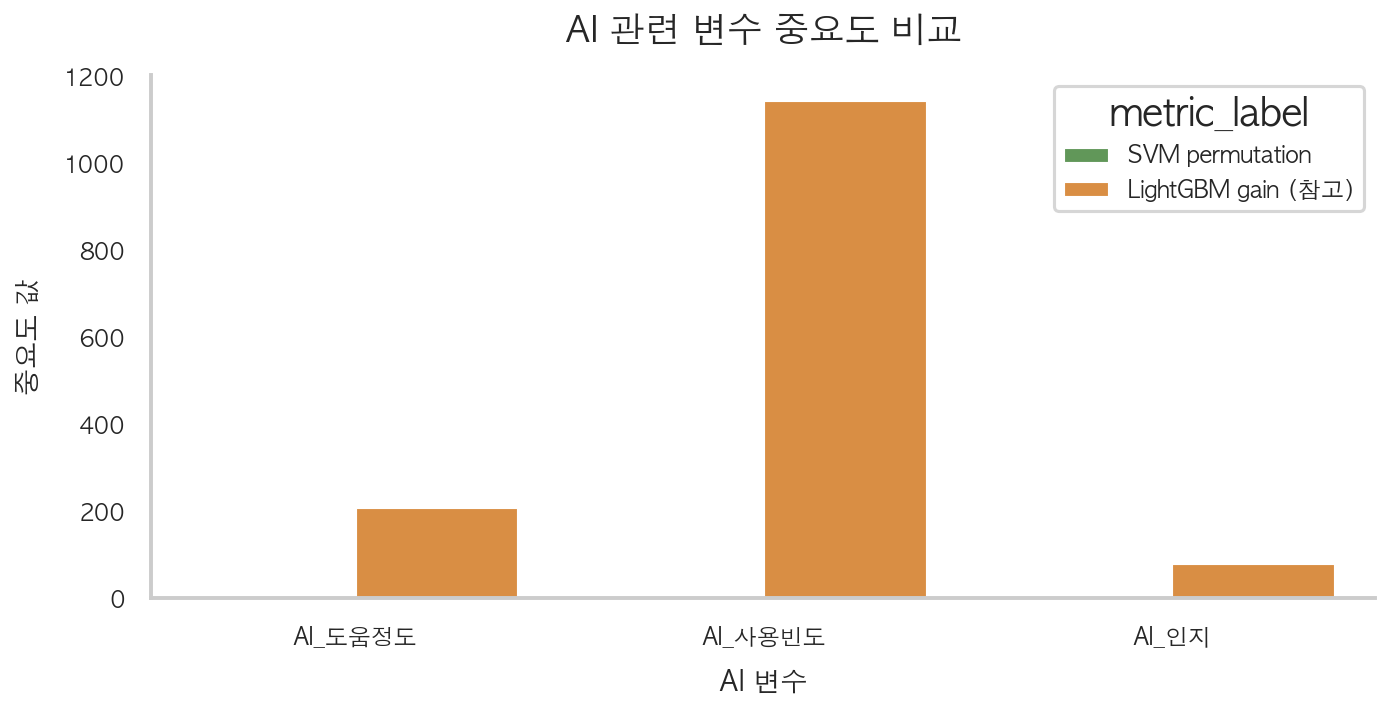

,feature,perm_importance,importance_gain,label
0,AI_도움정도,0.003169,210.409661,(Q27C 합산)
1,AI_사용빈도,0.002166,1146.427558,(Q27B 합산)
2,AI_인지,0.001608,79.833468,(Q27A 합산)


In [6]:
# 3. AI 관련 변수 중요도 비교 (SVM 중심)
ai_features = ["AI_인지", "AI_사용빈도", "AI_도움정도"]
ai_compare = (
    svm_perm[svm_perm["feature"].isin(ai_features)][["feature", "perm_importance"]]
    .merge(lgbm_imp[lgbm_imp["feature"].isin(ai_features)][["feature", "importance_gain"]], on="feature", how="left")
    .merge(feature_meta[["feature", "label"]], on="feature", how="left")
)
ai_plot = ai_compare.melt(id_vars=["feature", "label"], value_vars=["perm_importance", "importance_gain"], var_name="metric", value_name="value")
ai_plot["metric_label"] = ai_plot["metric"].map({"perm_importance": "SVM permutation", "importance_gain": "LightGBM gain (참고)"})

plt.figure(figsize=(10.5, 5.8))
ax = sns.barplot(data=ai_plot, x="feature", y="value", hue="metric_label", palette=["#59A14F", "#F28E2B"], errorbar=None)
set_axis_text(ax, "AI 관련 변수 중요도 비교", "AI 변수", "중요도 값", title_size=17)
apply_common_style(ax)
save_fig("03_ai_feature_comparison.png")

ai_compare


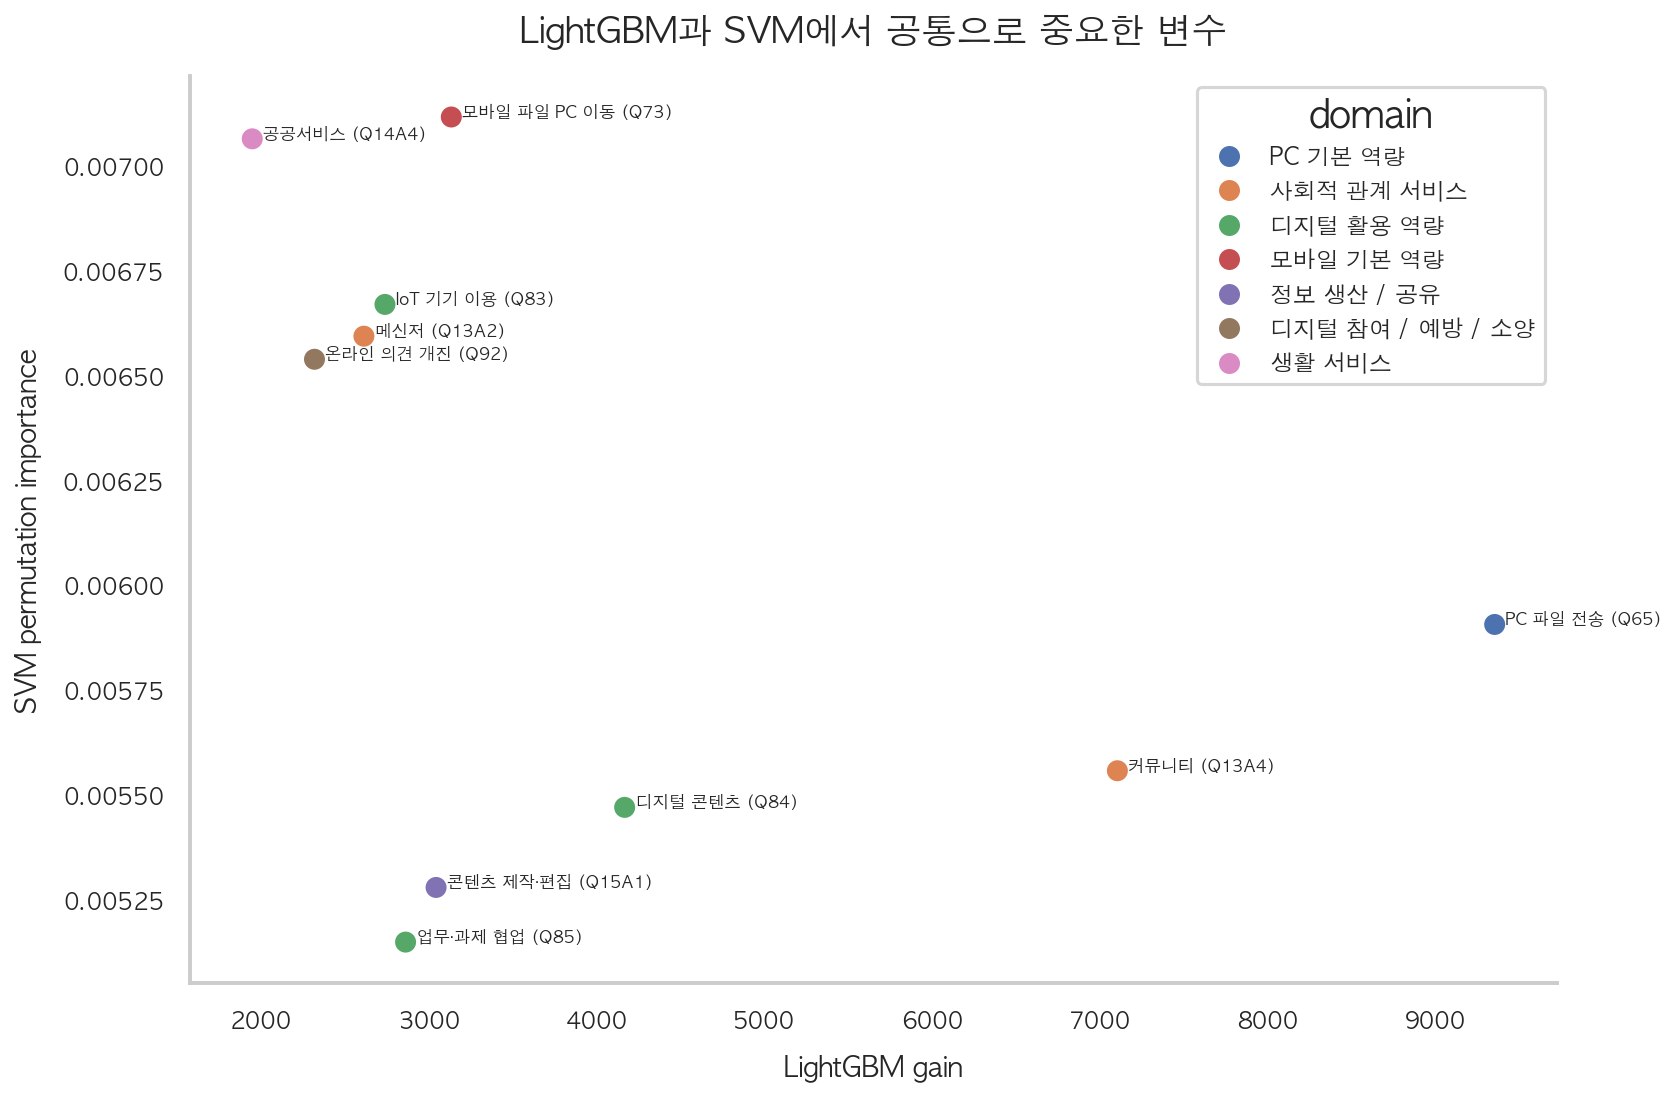

,feature,label_short,domain,importance_gain,perm_importance
0,Q6_5,PC 파일 전송 (Q65),PC 기본 역량,9354.710303,0.005906
1,Q13A_4,커뮤니티 (Q13A4),사회적 관계 서비스,7105.537563,0.005557
2,Q8_4,디지털 콘텐츠 (Q84),디지털 활용 역량,4168.275130,0.005470
3,Q7_3,모바일 파일 PC 이동 (Q73),모바일 기본 역량,3134.948914,0.007116
4,Q15A_1,콘텐츠 제작·편집 (Q15A1),정보 생산 / 공유,3044.183932,0.005279
5,Q8_5,업무·과제 협업 (Q85),디지털 활용 역량,2862.354048,0.005149
6,Q8_3,IoT 기기 이용 (Q83),디지털 활용 역량,2739.432011,0.006669
7,Q13A_2,메신저 (Q13A2),사회적 관계 서비스,2613.927552,0.006594
8,Q9_2,온라인 의견 개진 (Q92),디지털 참여 / 예방 / 소양,2319.299447,0.006539
9,Q14A_4,공공서비스 (Q14A4),생활 서비스,1948.293496,0.007064


In [7]:
# 4. LightGBM-SVM 공통 핵심 변수 비교
lgbm_rank = lgbm_imp.sort_values("importance_gain", ascending=False).head(20)[["feature", "label", "importance_gain", "domain"]].copy()
lgbm_rank["source"] = "LightGBM"
svm_rank = svm_perm.sort_values("perm_importance", ascending=False).head(20)[["feature", "label", "perm_importance", "domain"]].copy()
svm_rank["source"] = "SVM"

overlap = lgbm_rank[["feature", "label", "domain", "importance_gain"]].merge(
    svm_rank[["feature", "perm_importance"]],
    on="feature",
    how="inner",
)
overlap["label_short"] = make_unique_display_labels(
    overlap["feature"].tolist(),
    overlap["label"].tolist(),
    overlap.apply(lambda r: concise_feature_label(r["feature"], r["label"], max_len=10), axis=1).tolist(),
)
overlap = overlap.sort_values(["importance_gain", "perm_importance"], ascending=False)

plt.figure(figsize=(12.5, 8.6))
ax = sns.scatterplot(data=overlap, x="importance_gain", y="perm_importance", hue="domain", s=120)
for _, row in overlap.iterrows():
    ax.text(row["importance_gain"], row["perm_importance"], "  " + row["label_short"], fontsize=8)
set_axis_text(ax, "LightGBM과 SVM에서 공통으로 중요한 변수", "LightGBM gain", "SVM permutation importance", title_size=17)
apply_common_style(ax)
save_fig("04_overlap_scatter.png")

overlap[["feature", "label_short", "domain", "importance_gain", "perm_importance"]]


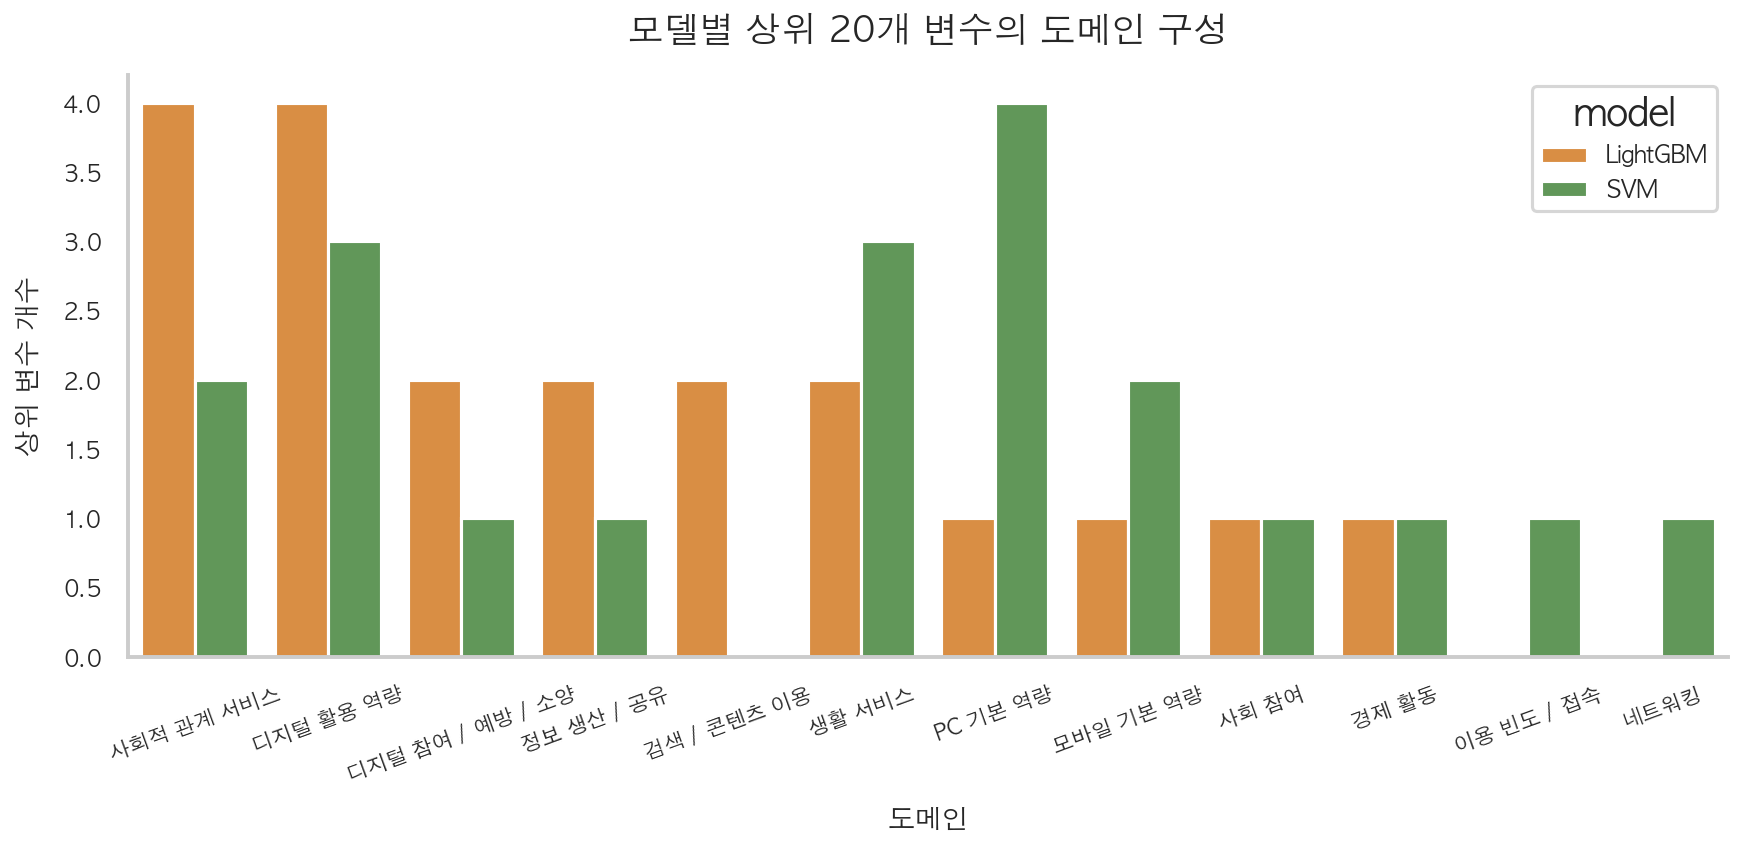

,domain,count,model
0,사회적 관계 서비스,4,LightGBM
1,디지털 활용 역량,4,LightGBM
2,디지털 참여 / 예방 / 소양,2,LightGBM
3,정보 생산 / 공유,2,LightGBM
4,검색 / 콘텐츠 이용,2,LightGBM
5,생활 서비스,2,LightGBM
6,PC 기본 역량,1,LightGBM
7,모바일 기본 역량,1,LightGBM
8,사회 참여,1,LightGBM
9,경제 활동,1,LightGBM


In [8]:
# 5. 모델별 상위 변수의 도메인 구성 비교
lgbm_domain_counts = lgbm_imp.sort_values("importance_gain", ascending=False).head(20)["domain"].value_counts()
lgbm_domain = pd.DataFrame({"domain": lgbm_domain_counts.index, "count": lgbm_domain_counts.values})
lgbm_domain["model"] = "LightGBM"
svm_domain_counts = svm_perm.sort_values("perm_importance", ascending=False).head(20)["domain"].value_counts()
svm_domain = pd.DataFrame({"domain": svm_domain_counts.index, "count": svm_domain_counts.values})
svm_domain["model"] = "SVM"
domain_compare = pd.concat([lgbm_domain, svm_domain], ignore_index=True)

plt.figure(figsize=(13.0, 6.8))
ax = sns.barplot(data=domain_compare, x="domain", y="count", hue="model", palette={"LightGBM": "#F28E2B", "SVM": "#59A14F"}, errorbar=None)
set_axis_text(ax, "모델별 상위 20개 변수의 도메인 구성", "도메인", "상위 변수 개수", title_size=17)
ax.tick_params(axis="x", rotation=20, labelsize=10)
apply_common_style(ax)
save_fig("05_domain_comparison.png")

domain_compare.sort_values(["model", "count"], ascending=[True, False])


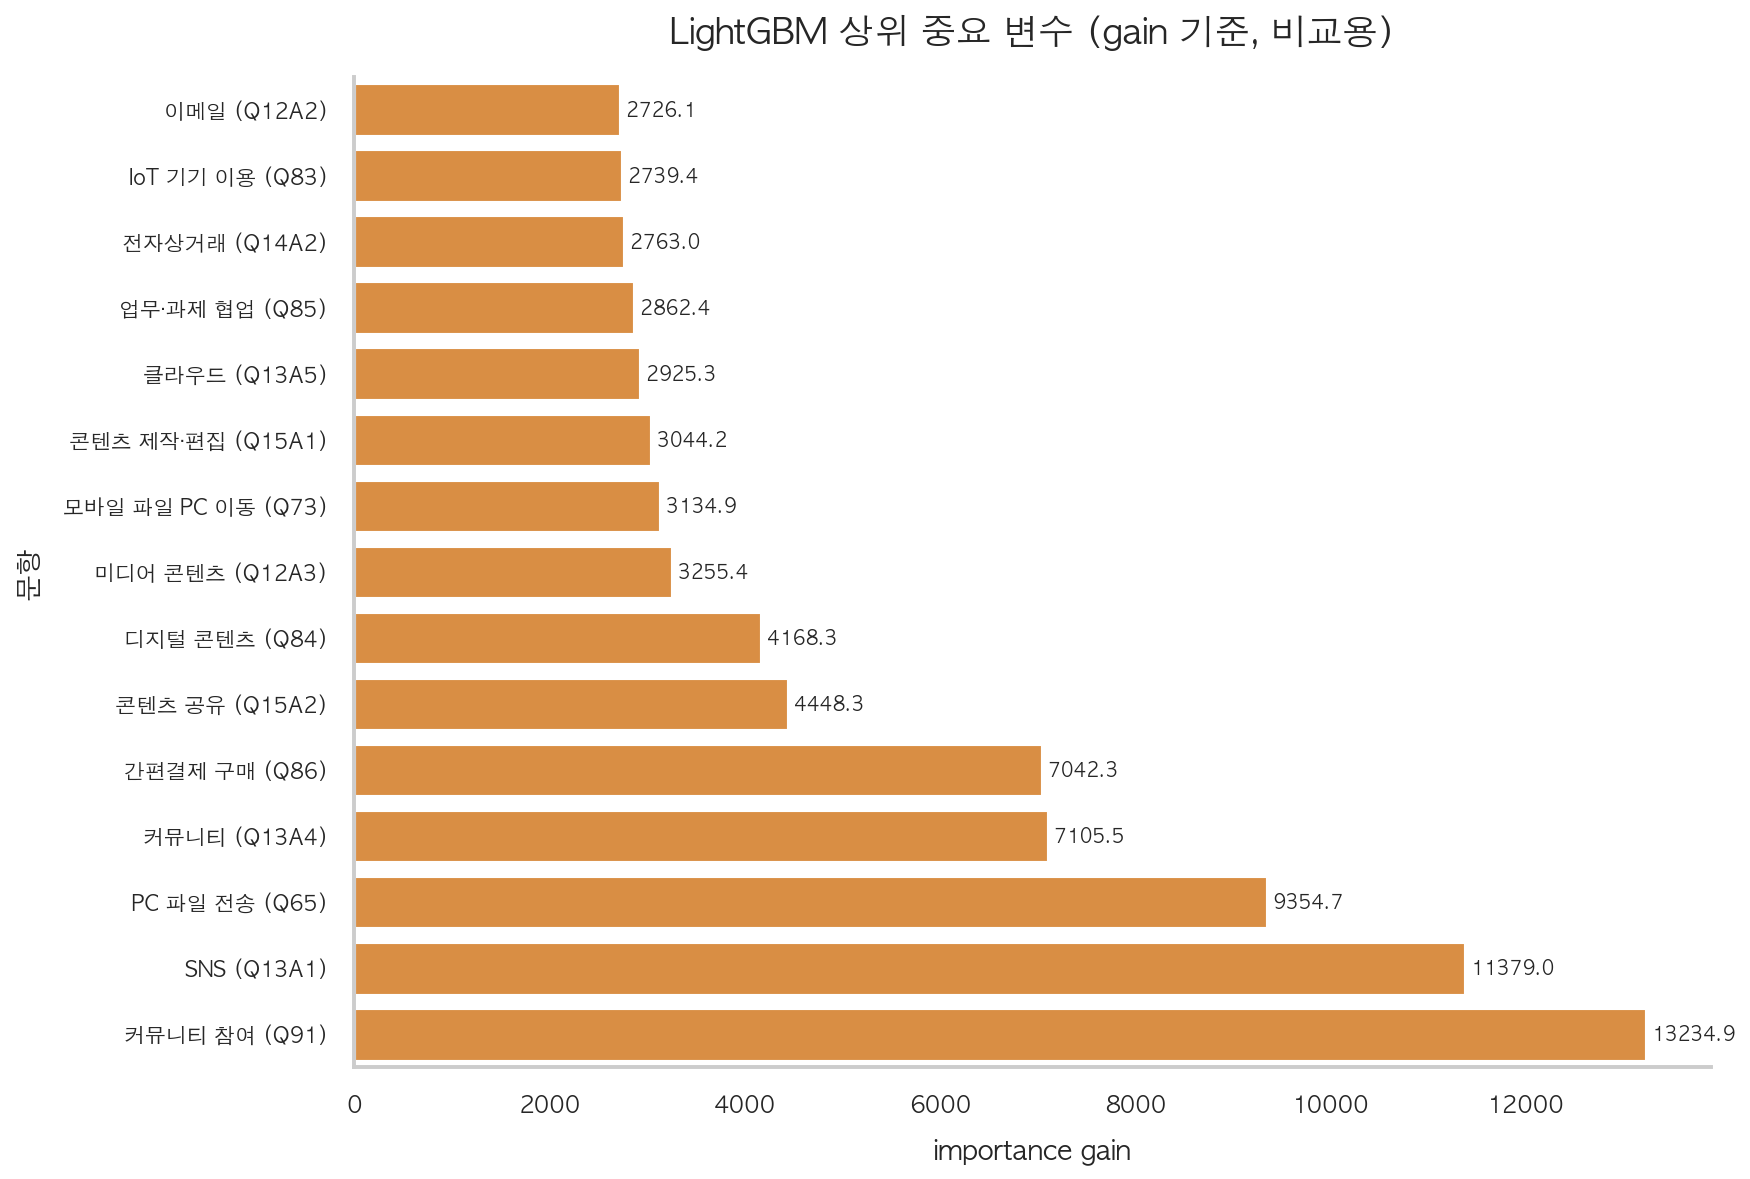

,feature,label_short,importance_gain,domain
61,Q9_1,커뮤니티 참여 (Q91),13234.934039,디지털 참여 / 예방 / 소양
85,Q13A_1,SNS (Q13A1),11378.983739,사회적 관계 서비스
70,Q6_5,PC 파일 전송 (Q65),9354.710303,PC 기본 역량
56,Q13A_4,커뮤니티 (Q13A4),7105.537563,사회적 관계 서비스
62,Q8_6,간편결제 구매 (Q86),7042.262320,디지털 활용 역량
37,Q15A_2,콘텐츠 공유 (Q15A2),4448.322538,정보 생산 / 공유
10,Q8_4,디지털 콘텐츠 (Q84),4168.275130,디지털 활용 역량
22,Q12A_3,미디어 콘텐츠 (Q12A3),3255.394204,검색 / 콘텐츠 이용
21,Q7_3,모바일 파일 PC 이동 (Q73),3134.948914,모바일 기본 역량
55,Q15A_1,콘텐츠 제작·편집 (Q15A1),3044.183932,정보 생산 / 공유


In [9]:
# 6. LightGBM 상위 중요 변수 (gain 기준, 비교용)
top_lgbm_gain = lgbm_imp.sort_values("importance_gain", ascending=False).head(15).sort_values("importance_gain")

plt.figure(figsize=(13.0, 9.2))
ax = sns.barplot(data=top_lgbm_gain, x="importance_gain", y="label_short", color="#F28E2B", errorbar=None)
set_axis_text(ax, "LightGBM 상위 중요 변수 (gain 기준, 비교용)", "importance gain", "문항", title_size=17)
ax.tick_params(axis="y", labelsize=10)
apply_common_style(ax)
add_horizontal_values(ax, decimals=1)
save_fig("06_lgbm_top_gain_reference.png")

top_lgbm_gain[["feature", "label_short", "importance_gain", "domain"]].sort_values("importance_gain", ascending=False)


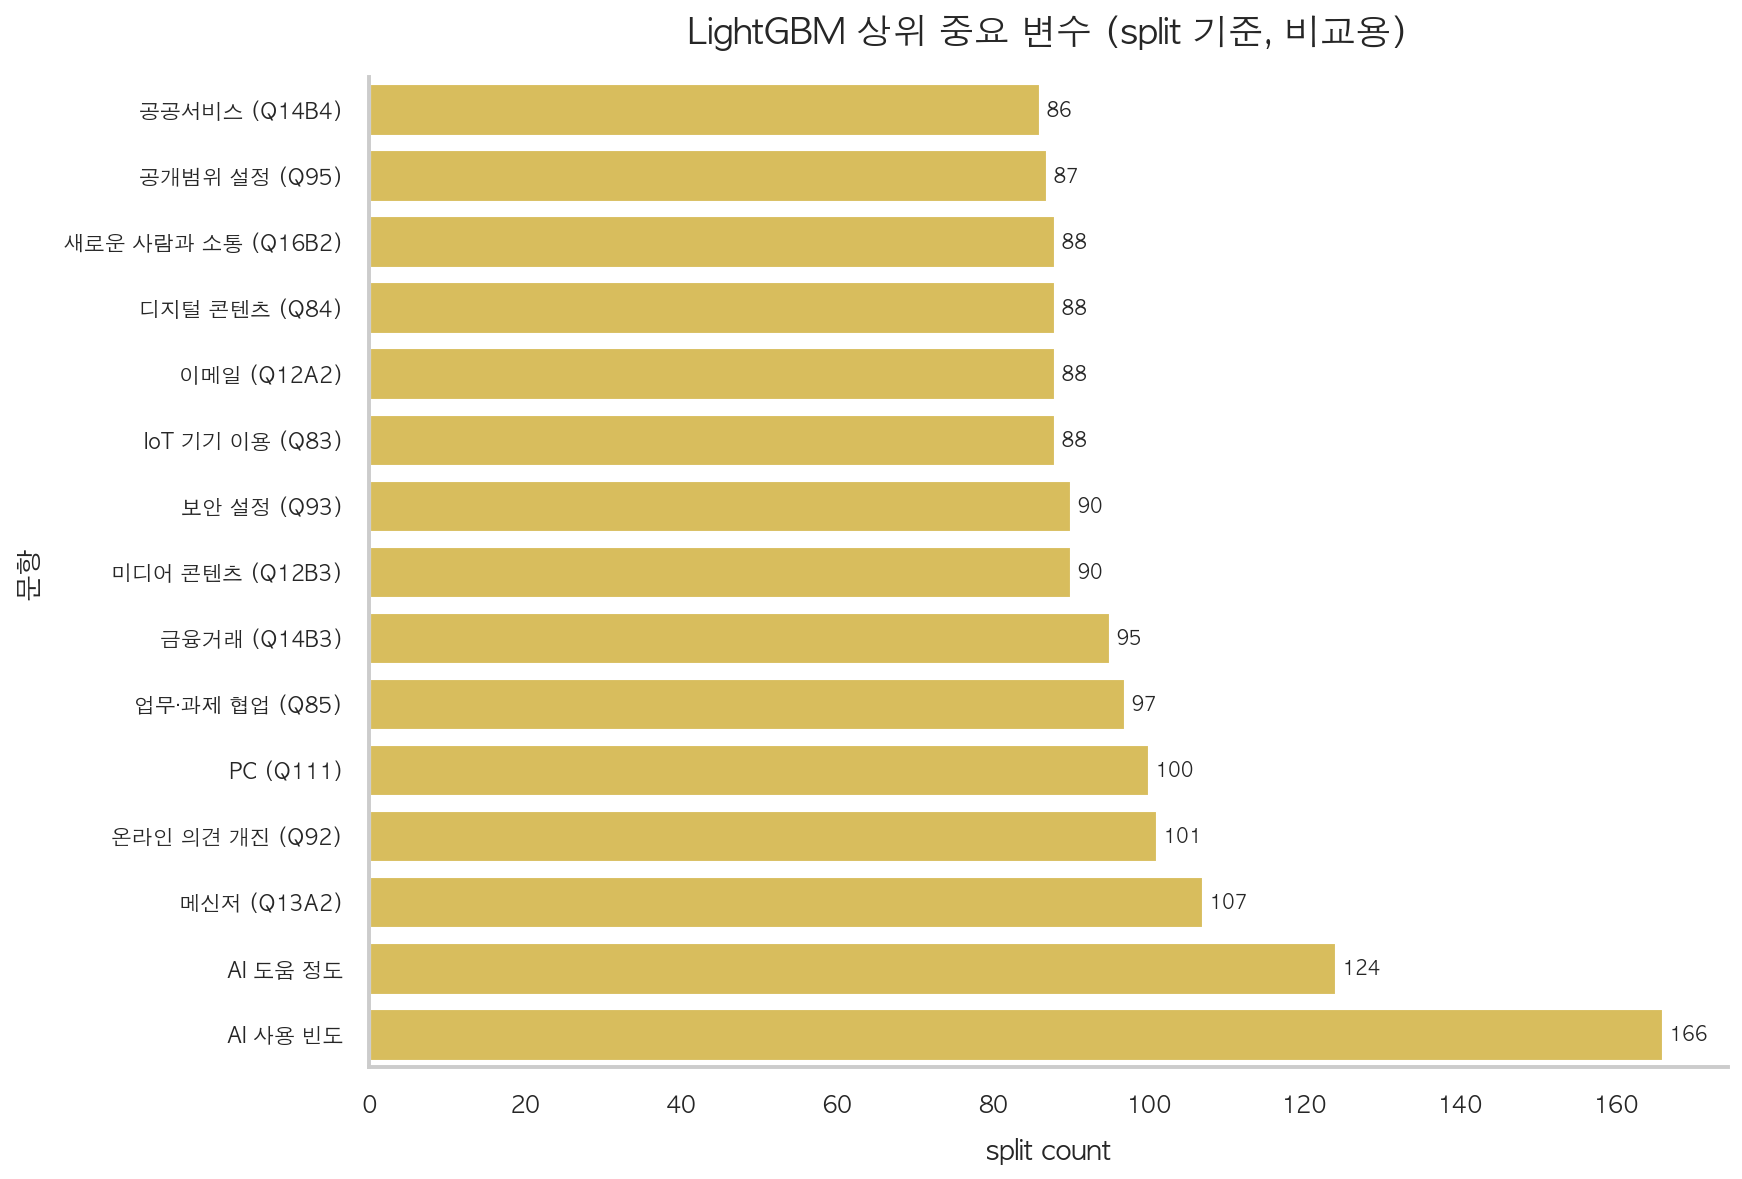

In [10]:
# 7. LightGBM 상위 중요 변수 (split 기준, 비교용)
top_lgbm_split = lgbm_imp.sort_values("importance_split", ascending=False).head(15).sort_values("importance_split")

plt.figure(figsize=(13.0, 9.2))
ax = sns.barplot(data=top_lgbm_split, x="importance_split", y="label_short", color="#EDC948", errorbar=None)
set_axis_text(ax, "LightGBM 상위 중요 변수 (split 기준, 비교용)", "split count", "문항", title_size=17)
ax.tick_params(axis="y", labelsize=10)
apply_common_style(ax)
add_horizontal_values(ax, decimals=0)
save_fig("07_lgbm_top_split_reference.png")


## LIME 사례 설명 (SVM 중심)

이 구간에서는 **최종 성능이 가장 좋았던 SVM**을 다시 학습한 뒤, LIME으로 개별 응답자 수준의 예측 이유를 설명합니다.

- 대표 사례는 `1단계`와 `3단계`에서 **정답으로 맞춘 샘플 중 예측 확률이 높은 사례**를 자동으로 고릅니다.
- LIME은 `왜 이 사람이 해당 단계로 분류되었는가`를 보여주는 사례형 XAI입니다.
- 아래 코드는 저장된 결과 CSV만 보는 것이 아니라, **SVM 최종 모델을 다시 재현해 실제 설명을 생성**합니다.


In [11]:
# 8. SVM + LIME 준비
import importlib
import src.xai_utils as xai_utils
importlib.reload(xai_utils)

from src.xai_utils import (
    CLASS_NAMES,
    create_lime_explainer,
    select_representative_case_indices,
    train_final_svm_for_xai,
)

lime_context = train_final_svm_for_xai(ROOT)

predict_proba_from_raw = lambda x: lime_context["calibrated_svc"].predict_proba(
    lime_context["scaler"].transform(np.asarray(x, dtype="float32"))
)

representative_cases = select_representative_case_indices(
    y_true=lime_context["y_test"],
    y_pred=lime_context["test_preds"],
    pred_proba=lime_context["test_probs"],
    target_classes=(0, 1, 2),
)

representative_summary = pd.DataFrame([
    {
        "class_id": class_idx,
        "stage": CLASS_NAMES[class_idx],
        "test_index": idx,
        "predicted_probability": round(float(lime_context["test_probs"][idx, class_idx]), 4),
    }
    for class_idx, idx in representative_cases.items()
])

lime_explainer = create_lime_explainer(
    x_train_raw=lime_context["X_train"],
    feature_names=lime_context["feature_display_names"],
    class_names=CLASS_NAMES,
)

representative_summary


,class_id,stage,test_index,predicted_probability
0,0,1단계_완전소외,1488,0.9997
1,1,2단계_부분적응,23,1.0000
2,2,3단계_자립적응,3474,1.0000


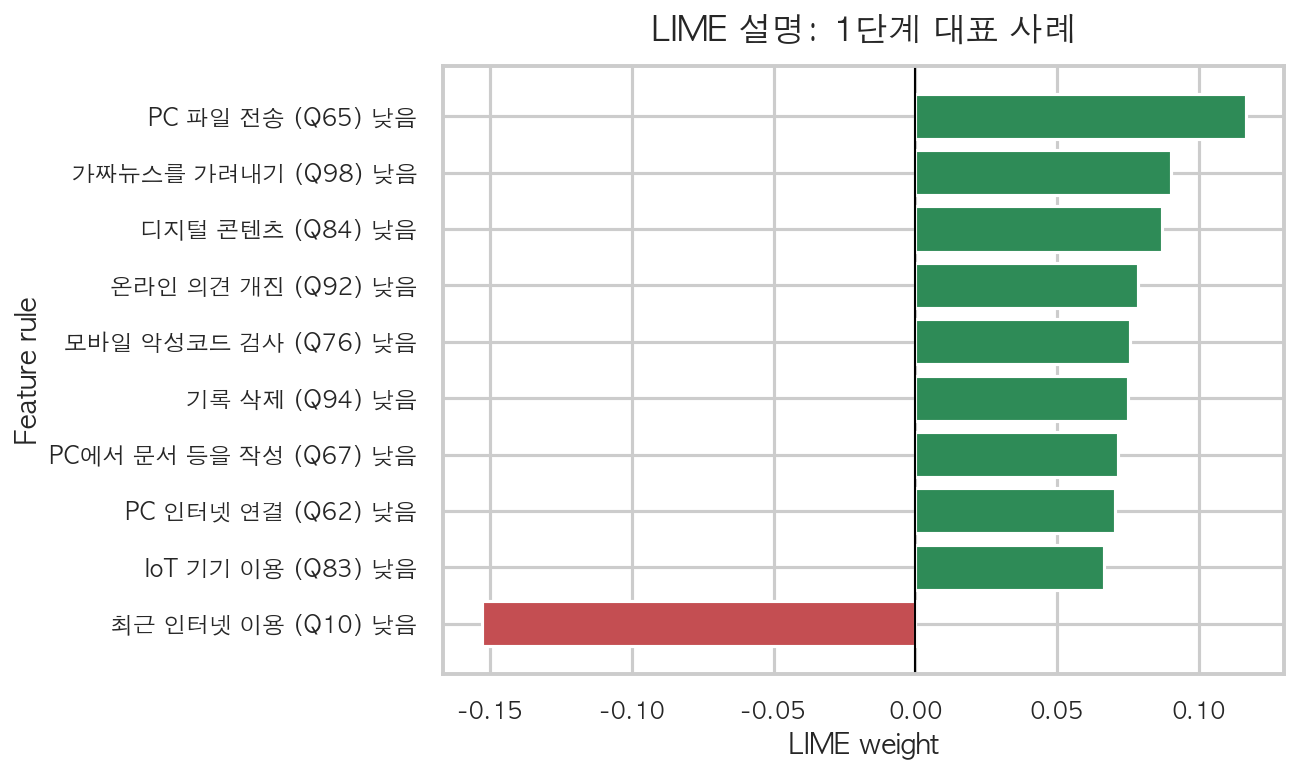

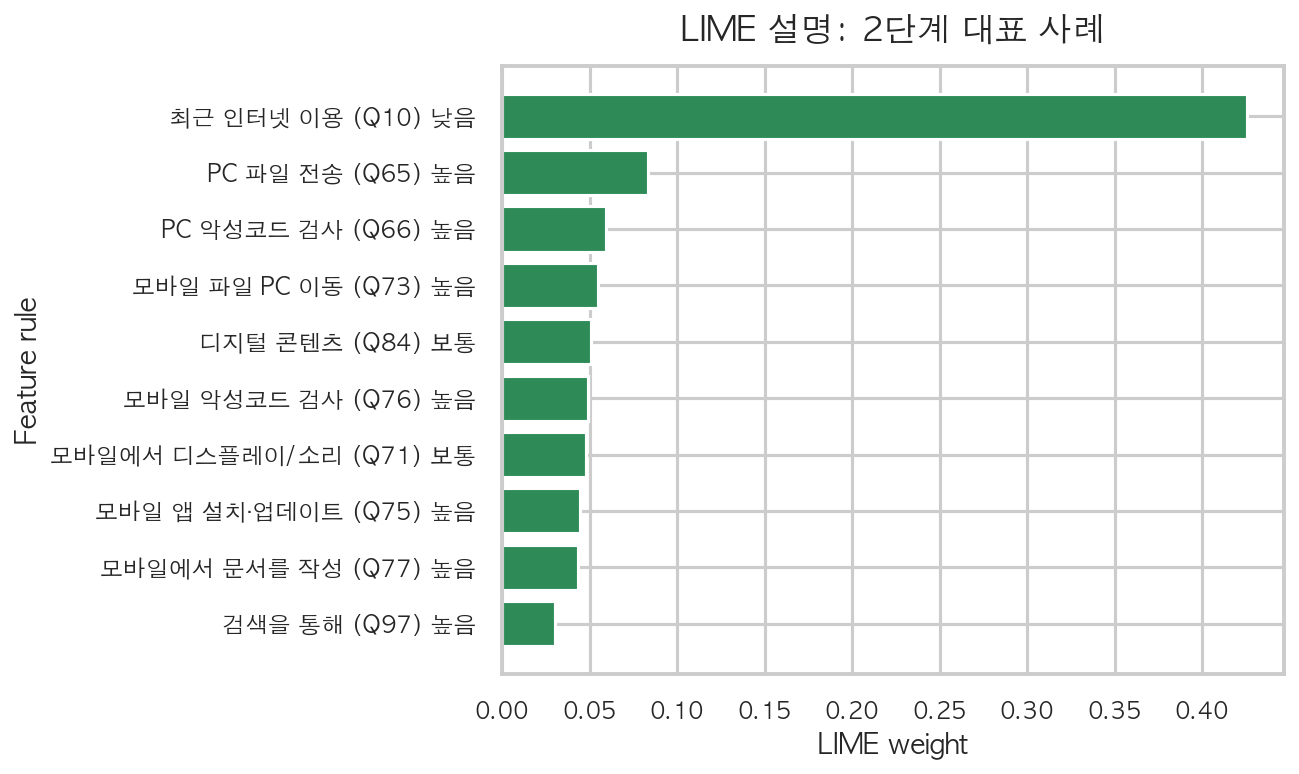

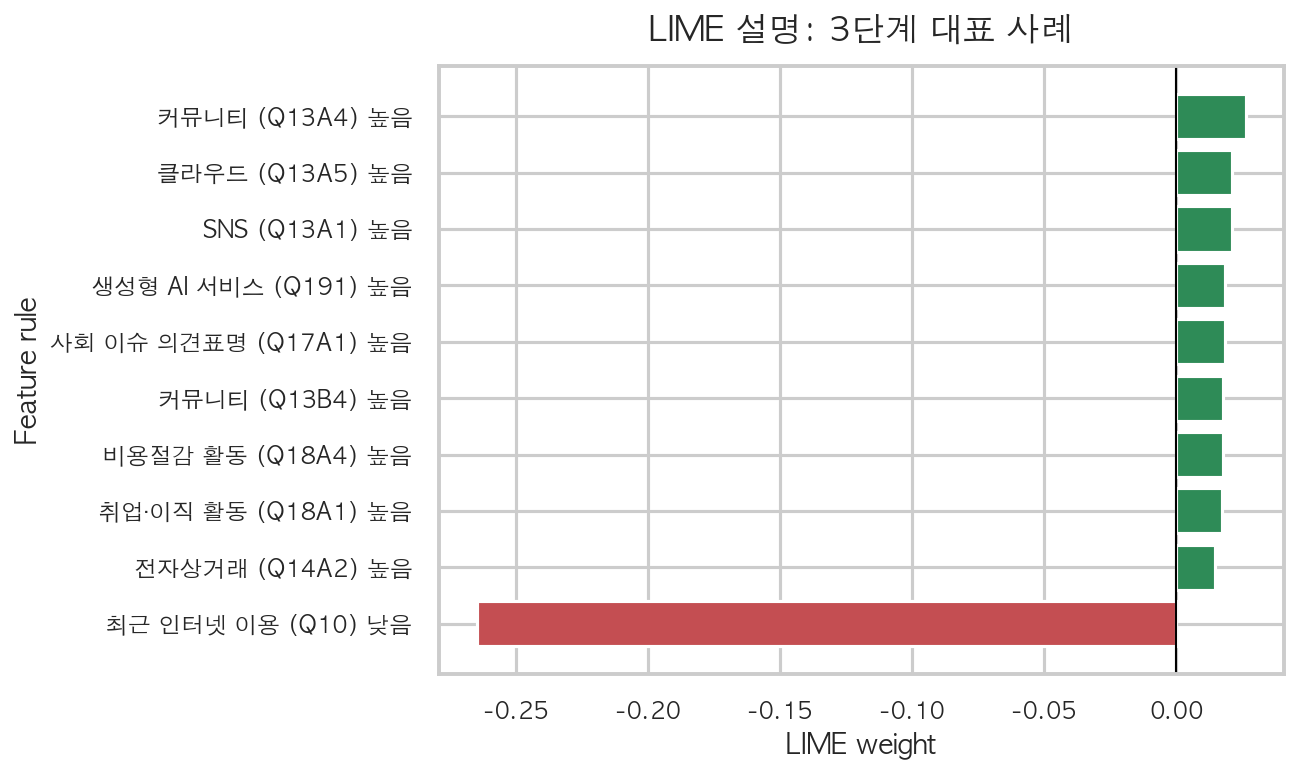

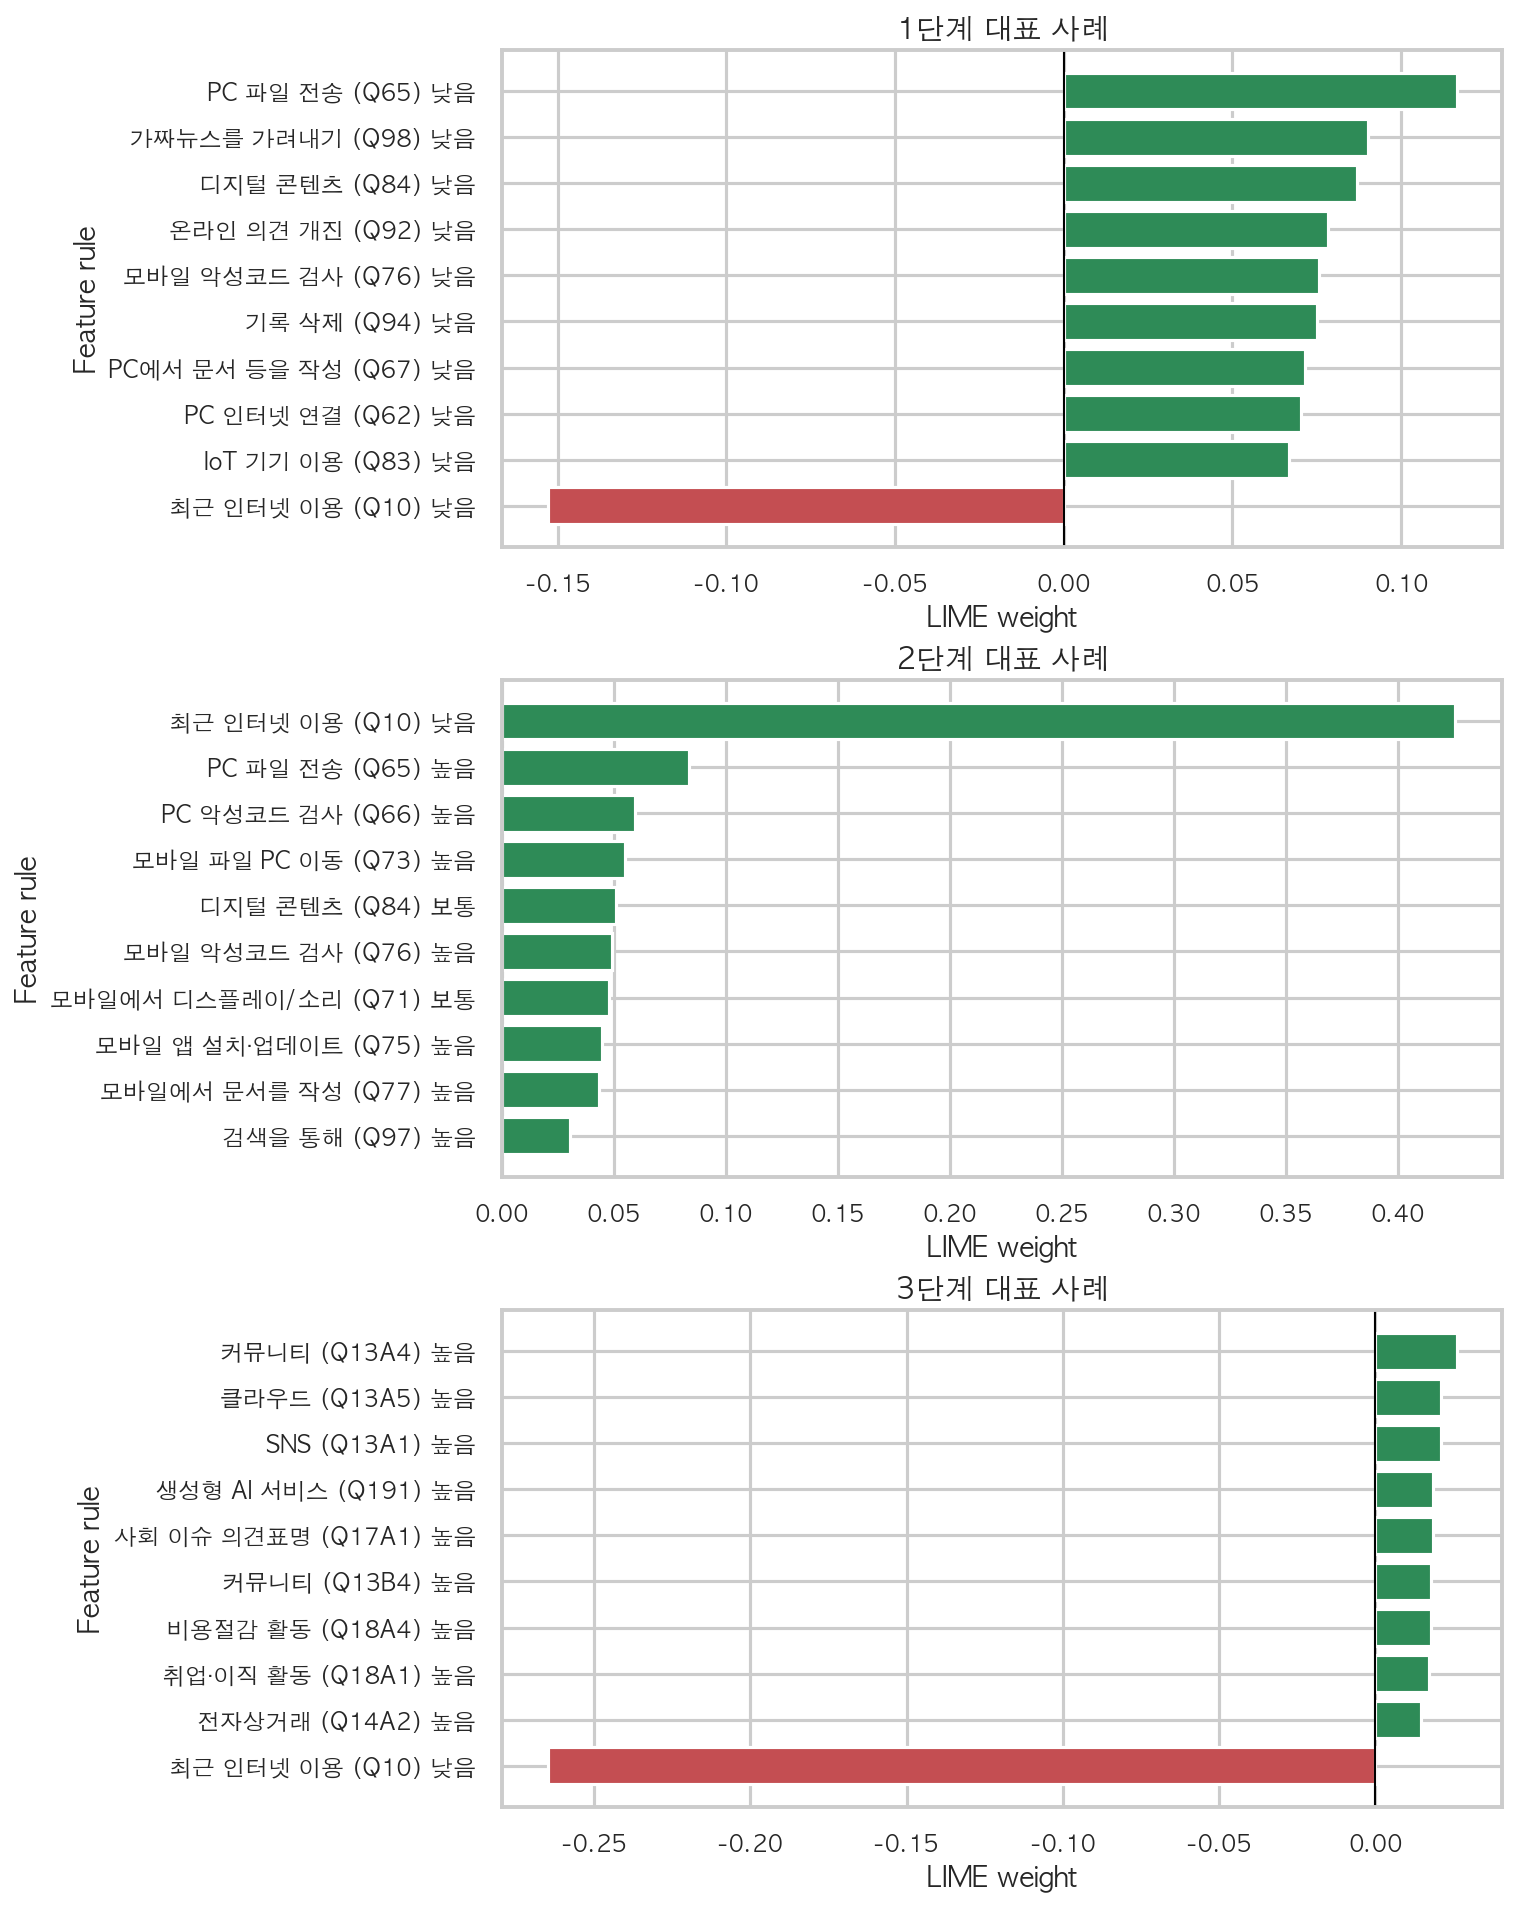

,rule_raw,rule,weight,abs_weight,direction
0,최근 인터넷 이용 (Q10) <= 1.00,최근 인터넷 이용 (Q10) 낮음,-0.152970,0.152970,negative
1,PC 파일 전송 (Q65) <= 1.00,PC 파일 전송 (Q65) 낮음,0.116551,0.116551,positive
2,가짜뉴스를 가려내기 (Q98) <= 1.00,가짜뉴스를 가려내기 (Q98) 낮음,0.090223,0.090223,positive
3,디지털 콘텐츠 (Q84) <= 1.00,디지털 콘텐츠 (Q84) 낮음,0.087030,0.087030,positive
4,온라인 의견 개진 (Q92) <= 1.00,온라인 의견 개진 (Q92) 낮음,0.078367,0.078367,positive
5,모바일 악성코드 검사 (Q76) <= 1.00,모바일 악성코드 검사 (Q76) 낮음,0.075793,0.075793,positive
6,기록 삭제 (Q94) <= 1.00,기록 삭제 (Q94) 낮음,0.075015,0.075015,positive
7,PC에서 문서 등을 작성 (Q67) <= 1.00,PC에서 문서 등을 작성 (Q67) 낮음,0.071637,0.071637,positive
8,PC 인터넷 연결 (Q62) <= 1.00,PC 인터넷 연결 (Q62) 낮음,0.070325,0.070325,positive
9,IoT 기기 이용 (Q83) <= 1.00,IoT 기기 이용 (Q83) 낮음,0.066654,0.066654,positive


,rule_raw,rule,weight,abs_weight,direction
0,최근 인터넷 이용 (Q10) <= 1.00,최근 인터넷 이용 (Q10) 낮음,0.425595,0.425595,positive
1,PC 파일 전송 (Q65) > 3.00,PC 파일 전송 (Q65) 높음,0.083391,0.083391,positive
2,PC 악성코드 검사 (Q66) > 3.00,PC 악성코드 검사 (Q66) 높음,0.059151,0.059151,positive
3,모바일 파일 PC 이동 (Q73) > 3.00,모바일 파일 PC 이동 (Q73) 높음,0.054714,0.054714,positive
4,1.00 < 디지털 콘텐츠 (Q84) <= 3.00,디지털 콘텐츠 (Q84) 보통,0.050821,0.050821,positive
5,모바일 악성코드 검사 (Q76) > 3.00,모바일 악성코드 검사 (Q76) 높음,0.048981,0.048981,positive
6,3.00 < 모바일에서 디스플레이/소리 (Q71) <= 4.00,모바일에서 디스플레이/소리 (Q71) 보통,0.047671,0.047671,positive
7,모바일 앱 설치·업데이트 (Q75) > 3.00,모바일 앱 설치·업데이트 (Q75) 높음,0.044777,0.044777,positive
8,모바일에서 문서를 작성 (Q77) > 3.00,모바일에서 문서를 작성 (Q77) 높음,0.043259,0.043259,positive
9,검색을 통해 (Q97) > 3.00,검색을 통해 (Q97) 높음,0.030152,0.030152,positive


,rule_raw,rule,weight,abs_weight,direction
0,최근 인터넷 이용 (Q10) <= 1.00,최근 인터넷 이용 (Q10) 낮음,-0.264891,0.264891,negative
1,커뮤니티 (Q13A4) > 2.00,커뮤니티 (Q13A4) 높음,0.026196,0.026196,positive
2,클라우드 (Q13A5) > 2.00,클라우드 (Q13A5) 높음,0.021187,0.021187,positive
3,SNS (Q13A1) > 2.00,SNS (Q13A1) 높음,0.021183,0.021183,positive
4,생성형 AI 서비스 (Q191) > 3.00,생성형 AI 서비스 (Q191) 높음,0.018559,0.018559,positive
5,사회 이슈 의견표명 (Q17A1) > 2.00,사회 이슈 의견표명 (Q17A1) 높음,0.018551,0.018551,positive
6,커뮤니티 (Q13B4) > 3.00,커뮤니티 (Q13B4) 높음,0.017750,0.017750,positive
7,비용절감 활동 (Q18A4) > 2.00,비용절감 활동 (Q18A4) 높음,0.017725,0.017725,positive
8,취업·이직 활동 (Q18A1) > 2.00,취업·이직 활동 (Q18A1) 높음,0.017349,0.017349,positive
9,전자상거래 (Q14A2) > 2.00,전자상거래 (Q14A2) 높음,0.014749,0.014749,positive


,rule_raw,rule,weight,abs_weight,direction,case_title
0,최근 인터넷 이용 (Q10) <= 1.00,최근 인터넷 이용 (Q10) 낮음,-0.152970,0.152970,negative,1단계 대표 사례
1,PC 파일 전송 (Q65) <= 1.00,PC 파일 전송 (Q65) 낮음,0.116551,0.116551,positive,1단계 대표 사례
2,가짜뉴스를 가려내기 (Q98) <= 1.00,가짜뉴스를 가려내기 (Q98) 낮음,0.090223,0.090223,positive,1단계 대표 사례
3,디지털 콘텐츠 (Q84) <= 1.00,디지털 콘텐츠 (Q84) 낮음,0.087030,0.087030,positive,1단계 대표 사례
4,온라인 의견 개진 (Q92) <= 1.00,온라인 의견 개진 (Q92) 낮음,0.078367,0.078367,positive,1단계 대표 사례
5,모바일 악성코드 검사 (Q76) <= 1.00,모바일 악성코드 검사 (Q76) 낮음,0.075793,0.075793,positive,1단계 대표 사례
6,기록 삭제 (Q94) <= 1.00,기록 삭제 (Q94) 낮음,0.075015,0.075015,positive,1단계 대표 사례
7,PC에서 문서 등을 작성 (Q67) <= 1.00,PC에서 문서 등을 작성 (Q67) 낮음,0.071637,0.071637,positive,1단계 대표 사례
8,PC 인터넷 연결 (Q62) <= 1.00,PC 인터넷 연결 (Q62) 낮음,0.070325,0.070325,positive,1단계 대표 사례
9,IoT 기기 이용 (Q83) <= 1.00,IoT 기기 이용 (Q83) 낮음,0.066654,0.066654,positive,1단계 대표 사례


In [12]:
# 8-10. 대표 사례 LIME 설명 생성 (1·2·3단계)
from src.xai_utils import explain_with_lime, plot_lime_case_comparison, plot_lime_explanation

case0_idx = representative_cases[0]
case1_idx = representative_cases[1]
case2_idx = representative_cases[2]

case0_df = explain_with_lime(
    lime_explainer,
    predict_fn=predict_proba_from_raw,
    sample_raw=lime_context["X_test"][case0_idx],
    predicted_label=int(lime_context["test_preds"][case0_idx]),
    num_features=10,
)
plot_lime_explanation(
    case0_df,
    title="LIME 설명: 1단계 대표 사례",
    save_path=OUT_DIR / "08_lime_case_stage1.png",
)

case1_df = explain_with_lime(
    lime_explainer,
    predict_fn=predict_proba_from_raw,
    sample_raw=lime_context["X_test"][case1_idx],
    predicted_label=int(lime_context["test_preds"][case1_idx]),
    num_features=10,
)
plot_lime_explanation(
    case1_df,
    title="LIME 설명: 2단계 대표 사례",
    save_path=OUT_DIR / "08b_lime_case_stage2.png",
)

case2_df = explain_with_lime(
    lime_explainer,
    predict_fn=predict_proba_from_raw,
    sample_raw=lime_context["X_test"][case2_idx],
    predicted_label=int(lime_context["test_preds"][case2_idx]),
    num_features=10,
)
plot_lime_explanation(
    case2_df,
    title="LIME 설명: 3단계 대표 사례",
    save_path=OUT_DIR / "09_lime_case_stage3.png",
)

lime_case_compare = plot_lime_case_comparison(
    case_frames=[case0_df, case1_df, case2_df],
    case_titles=["1단계 대표 사례", "2단계 대표 사례", "3단계 대표 사례"],
    save_path=OUT_DIR / "10_lime_case_comparison.png",
)

display(case0_df.sort_values("abs_weight", ascending=False).head(10))
display(case1_df.sort_values("abs_weight", ascending=False).head(10))
display(case2_df.sort_values("abs_weight", ascending=False).head(10))
lime_case_compare

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


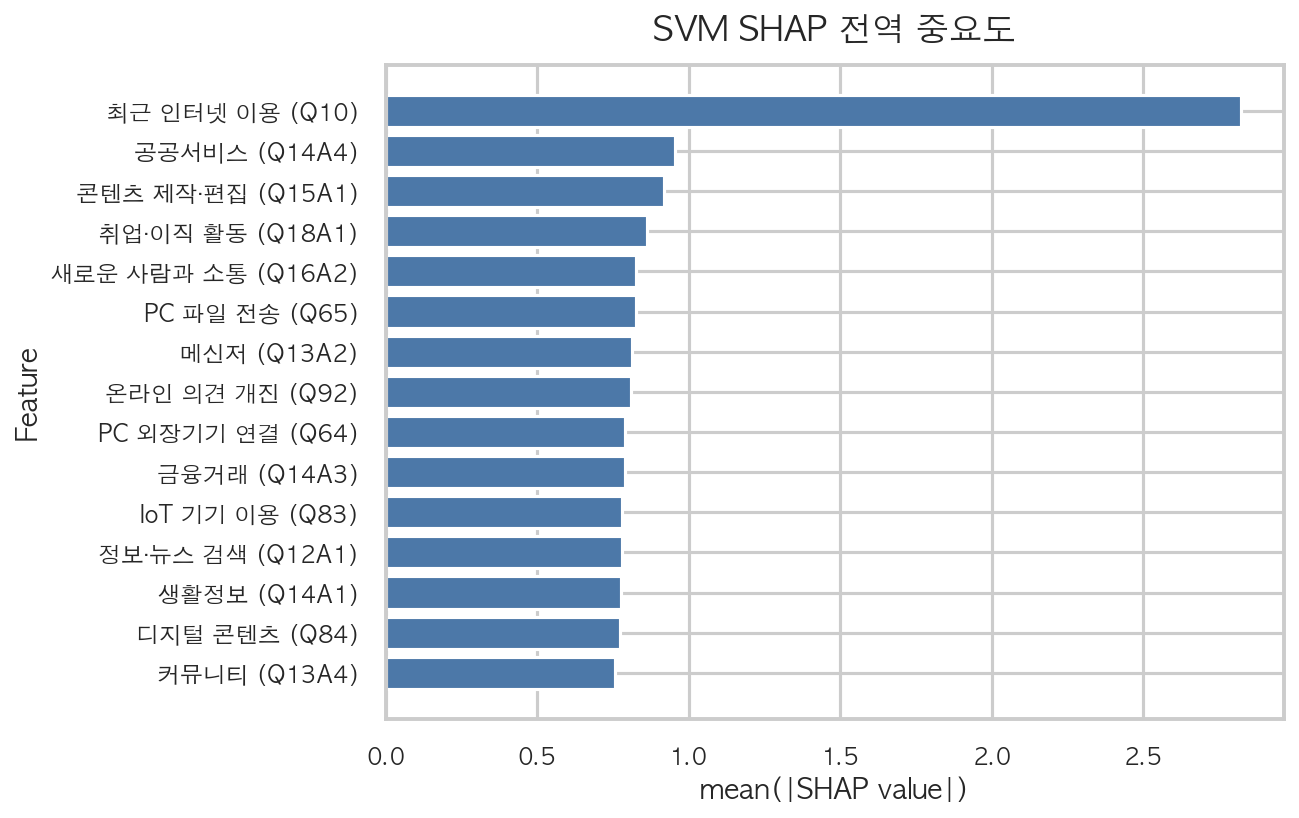

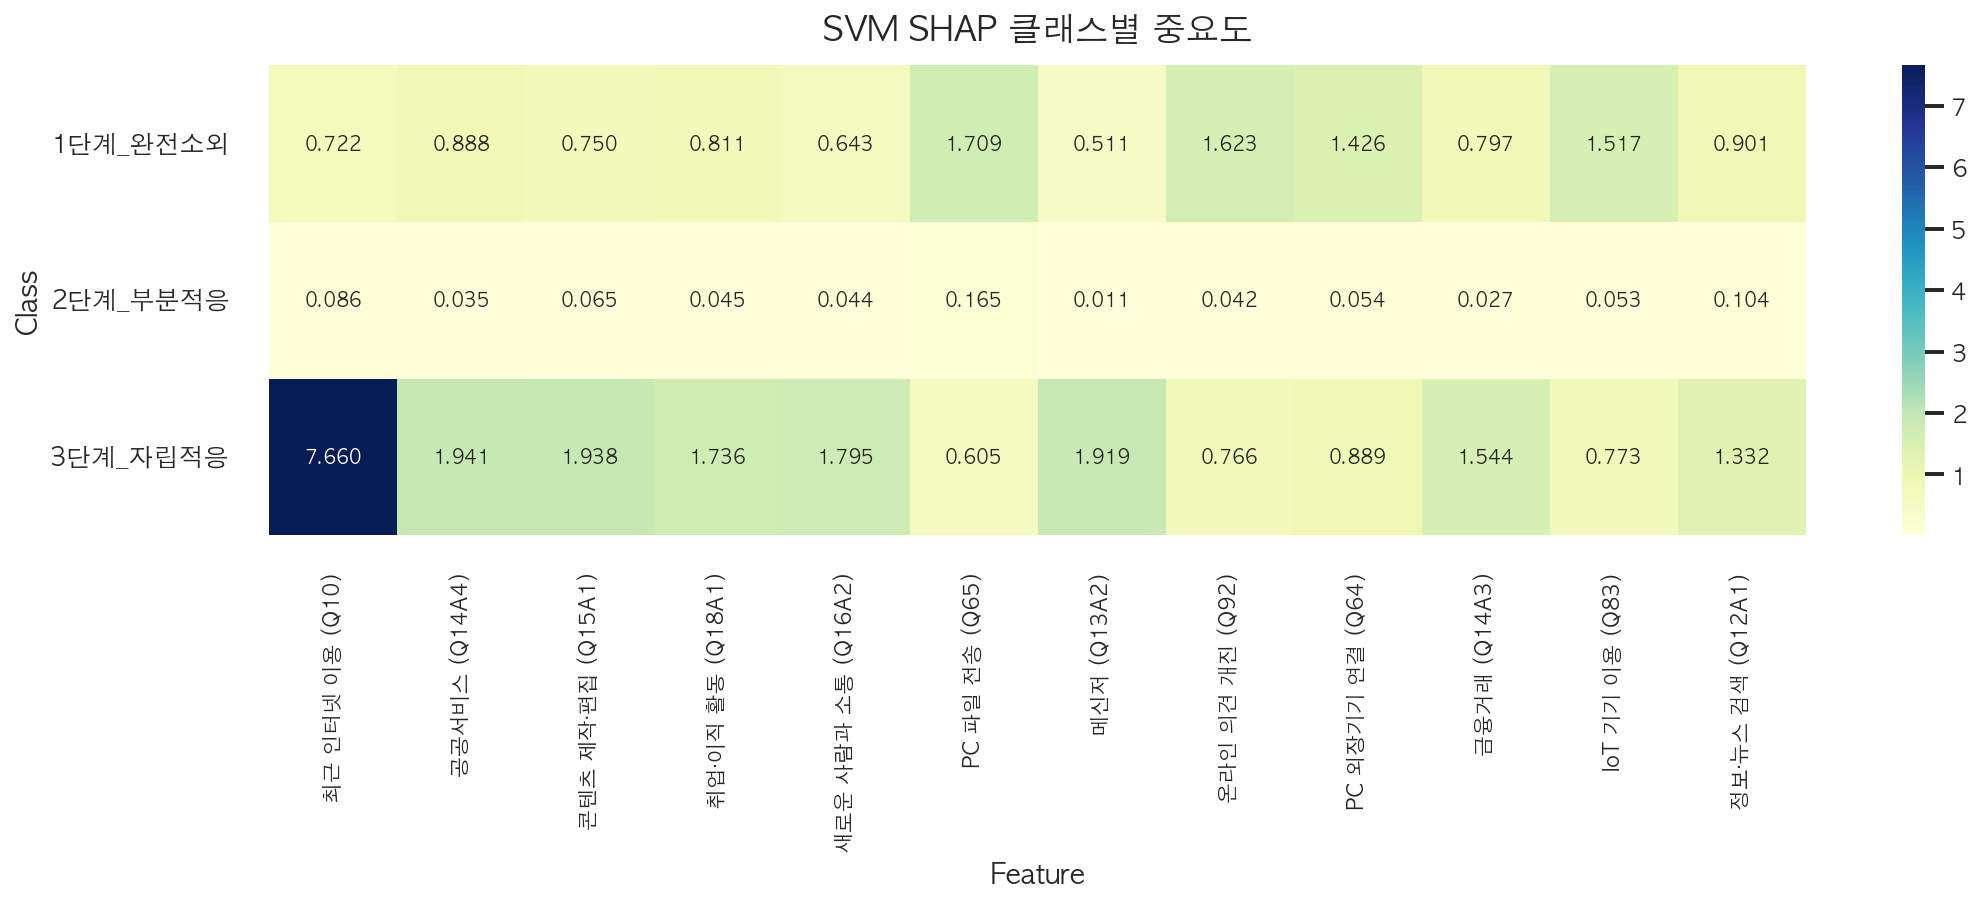

,feature,mean_abs_shap
0,최근 인터넷 이용 (Q10),2.822498
1,공공서비스 (Q14A4),0.954814
2,콘텐츠 제작·편집 (Q15A1),0.917764
3,취업·이직 활동 (Q18A1),0.863682
4,새로운 사람과 소통 (Q16A2),0.827243
5,PC 파일 전송 (Q65),0.826256
6,메신저 (Q13A2),0.813841
7,온라인 의견 개진 (Q92),0.810189
8,PC 외장기기 연결 (Q64),0.789508
9,금융거래 (Q14A3),0.789153


,최근 인터넷 이용 (Q10),공공서비스 (Q14A4),콘텐츠 제작·편집 (Q15A1),취업·이직 활동 (Q18A1),새로운 사람과 소통 (Q16A2),PC 파일 전송 (Q65),메신저 (Q13A2),온라인 의견 개진 (Q92),PC 외장기기 연결 (Q64),금융거래 (Q14A3),IoT 기기 이용 (Q83),정보·뉴스 검색 (Q12A1)
1단계_완전소외,0.721569,0.888400,0.750245,0.810750,0.643361,1.708920,0.511452,1.623201,1.426391,0.796656,1.516563,0.900908
2단계_부분적응,0.085765,0.034894,0.065031,0.044782,0.043790,0.165223,0.011128,0.041672,0.053577,0.027269,0.052656,0.104333
3단계_자립적응,7.660162,1.941149,1.938016,1.735512,1.794579,0.604624,1.918943,0.765693,0.888556,1.543535,0.773032,1.331685


In [13]:
# 11-12. SVM + SHAP 전역 설명
import importlib
import src.xai_utils as xai_utils
importlib.reload(xai_utils)

from src.xai_utils import (
    compute_shap_bundle,
    create_shap_linear_explainer,
    plot_shap_class_heatmap,
    plot_shap_global_importance,
)

shap_explainer = create_shap_linear_explainer(
    linear_model=lime_context["final_svc"],
    x_background_scaled=lime_context["X_train_scaled"],
    max_background=1000,
)

shap_bundle = compute_shap_bundle(
    shap_explainer,
    lime_context["X_test_scaled"],
    class_names=CLASS_NAMES,
    max_samples=800,
)

shap_global_df = plot_shap_global_importance(
    shap_bundle,
    feature_names=lime_context["feature_display_names"],
    save_path=OUT_DIR / "11_svm_shap_global_importance.png",
    top_n=15,
)

shap_heatmap_df = plot_shap_class_heatmap(
    shap_bundle,
    feature_names=lime_context["feature_display_names"],
    save_path=OUT_DIR / "12_svm_shap_class_heatmap.png",
    top_n=12,
)

display(shap_global_df.head(15))
shap_heatmap_df


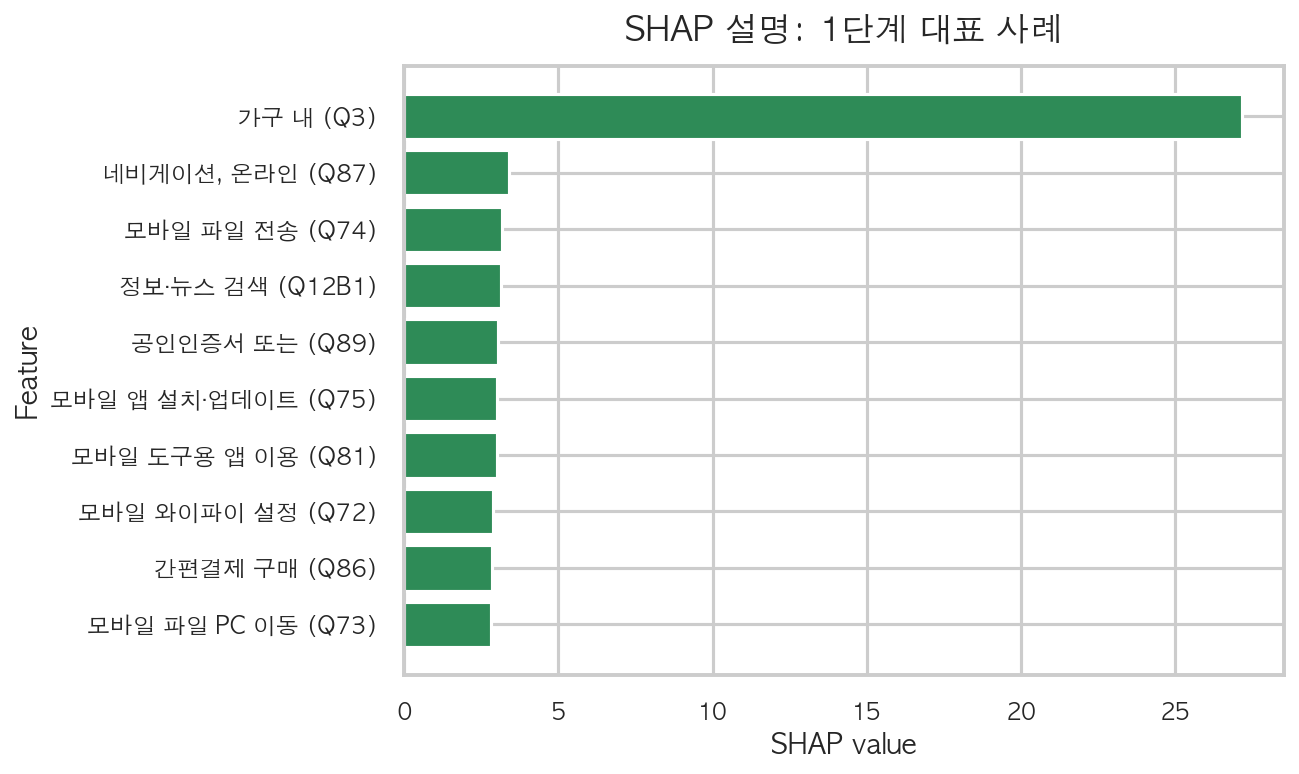

,feature,feature_value,shap_value,abs_shap,direction
0,가구 내 (Q3),-33.739643,27.180397,27.180397,positive
1,"네비게이션, 온라인 (Q87)",-2.190655,3.400832,3.400832,positive
2,모바일 파일 전송 (Q74),-1.931786,3.166001,3.166001,positive
3,정보·뉴스 검색 (Q12B1),-2.697333,3.124791,3.124791,positive
4,공인인증서 또는 (Q89),-1.827309,3.030027,3.030027,positive
5,모바일 앱 설치·업데이트 (Q75),-1.661816,3.001424,3.001424,positive
6,모바일 도구용 앱 이용 (Q81),-1.741546,2.993981,2.993981,positive
7,모바일 와이파이 설정 (Q72),-1.807772,2.880394,2.880394,positive
8,간편결제 구매 (Q86),-1.653080,2.853088,2.853088,positive
9,모바일 파일 PC 이동 (Q73),-1.457276,2.800076,2.800076,positive


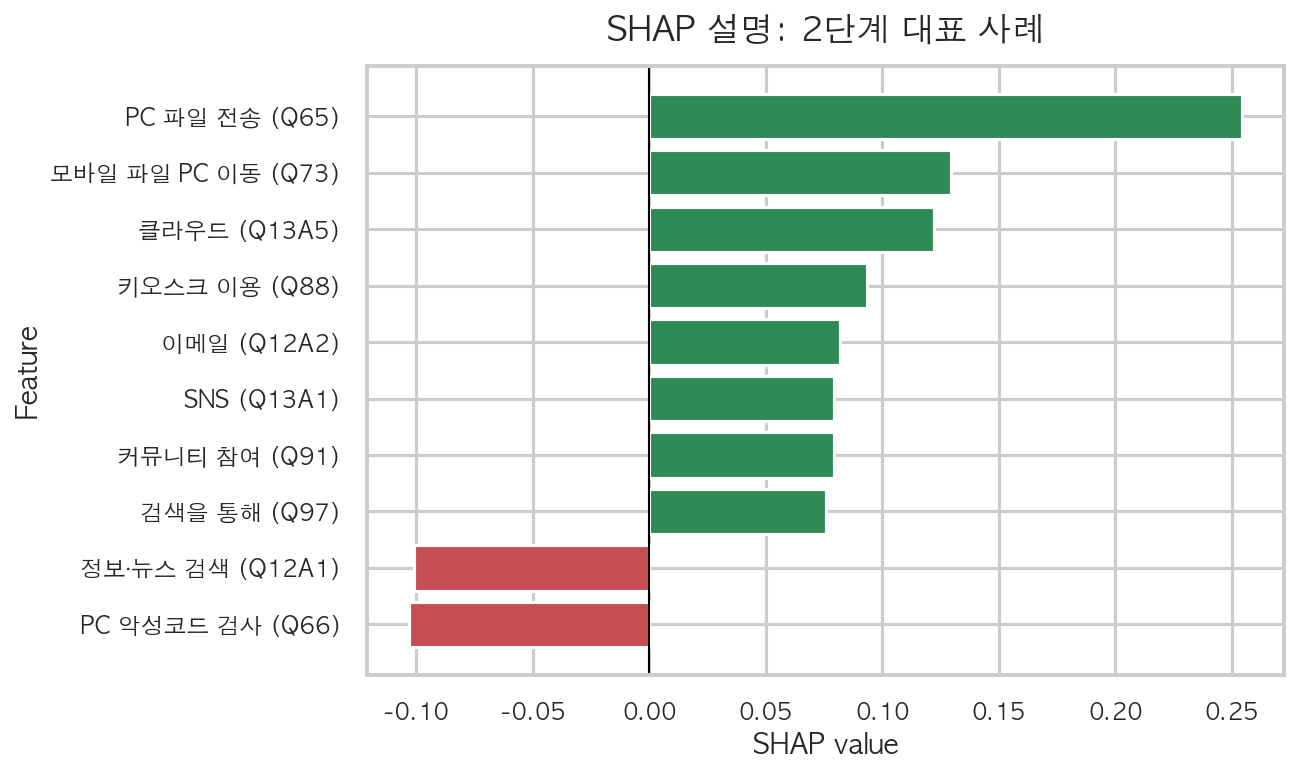

,feature,feature_value,shap_value,abs_shap,direction
0,PC 파일 전송 (Q65),1.407338,0.254462,0.254462,positive
1,모바일 파일 PC 이동 (Q73),1.327159,0.129585,0.129585,positive
2,클라우드 (Q13A5),-0.551246,0.122133,0.122133,positive
3,PC 악성코드 검사 (Q66),1.774829,-0.103058,0.103058,negative
4,정보·뉴스 검색 (Q12A1),-0.799358,-0.100967,0.100967,negative
5,키오스크 이용 (Q88),1.187427,0.093347,0.093347,positive
6,이메일 (Q12A2),-0.670103,0.082015,0.082015,positive
7,SNS (Q13A1),-0.596375,0.079237,0.079237,positive
8,커뮤니티 참여 (Q91),0.519347,0.079085,0.079085,positive
9,검색을 통해 (Q97),1.597776,0.076010,0.076010,positive


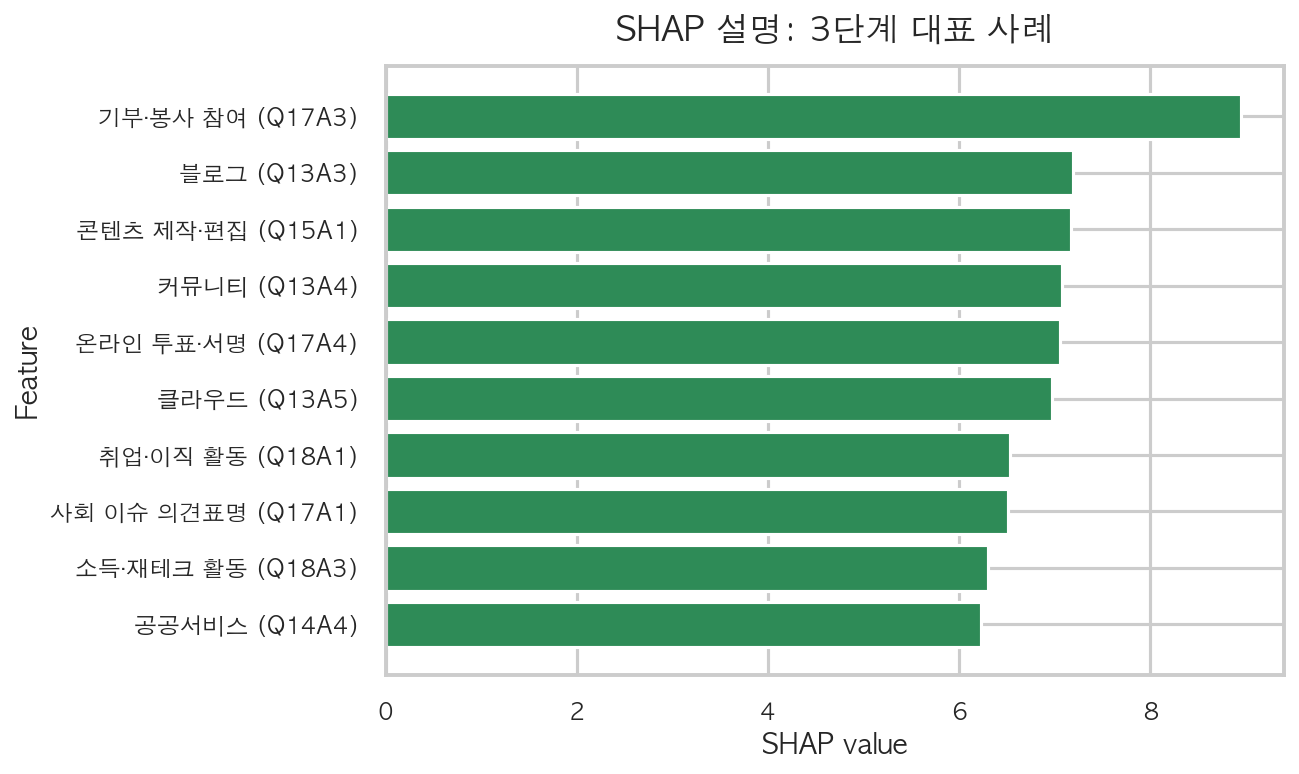

,feature,feature_value,shap_value,abs_shap,direction
0,기부·봉사 참여 (Q17A3),3.999017,8.954537,8.954537,positive
1,블로그 (Q13A3),3.322269,7.189560,7.189560,positive
2,콘텐츠 제작·편집 (Q15A1),3.058004,7.175202,7.175202,positive
3,커뮤니티 (Q13A4),3.278948,7.076535,7.076535,positive
4,온라인 투표·서명 (Q17A4),3.849365,7.060669,7.060669,positive
5,클라우드 (Q13A5),3.315601,6.977796,6.977796,positive
6,취업·이직 활동 (Q18A1),3.077004,6.535025,6.535025,positive
7,사회 이슈 의견표명 (Q17A1),3.258663,6.515234,6.515234,positive
8,소득·재테크 활동 (Q18A3),3.113254,6.308437,6.308437,positive
9,공공서비스 (Q14A4),2.855718,6.235489,6.235489,positive


In [14]:
# 13-15. 대표 사례 SHAP 설명 생성 (1·2·3단계)
from src.xai_utils import prepare_shap_case_frame, plot_shap_case_explanation

case0_class = int(lime_context["test_preds"][case0_idx])
case1_class = int(lime_context["test_preds"][case1_idx])
case2_class = int(lime_context["test_preds"][case2_idx])

for case_idx, case_class, stage_label, fname in [
    (case0_idx, case0_class, "1단계 대표 사례", "13_svm_shap_case_stage1.png"),
    (case1_idx, case1_class, "2단계 대표 사례", "13b_svm_shap_case_stage2.png"),
    (case2_idx, case2_class, "3단계 대표 사례", "14_svm_shap_case_stage3.png"),
]:
    bundle = compute_shap_bundle(
        shap_explainer,
        lime_context["X_test_scaled"][case_idx:case_idx + 1],
        class_names=CLASS_NAMES,
    )
    case_df = prepare_shap_case_frame(
        bundle,
        feature_names=lime_context["feature_display_names"],
        sample_index=0,
        class_index=case_class,
        top_n=10,
    )
    plot_shap_case_explanation(
        case_df,
        title=f"SHAP 설명: {stage_label}",
        save_path=OUT_DIR / fname,
    )
    display(case_df.sort_values("abs_shap", ascending=False))